In [95]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sympy import lambdify
import sympy as sp

# 1. Point Python to your exact SRC directory
sys.path.append("/Users/adarshmac/simulations/bbh_run1/ANALYTICAL_CODES/SRC")

# 2. Import the engine AND EVERY metric available in your library
from Testsymbolicengine import (
    calculate_automated_fields, get_schwarzschild_spherical, get_schwarzschild_isotropic,
    get_reissner_nordstrom_spherical, get_reissner_nordstrom_isotropic,
    get_flrw_cartesian, get_bardeen_spherical,get_bardeen_cartesian, get_kerr_boyer_lindquist,
    get_kerr_quasi_isotropic_spherical, get_kerr_schild_cartesian
)

# 3. Load the geometry 
print("Loading Metric Geometry...")
metric_data = get_schwarzschild_isotropic()  # Change this to load different metrics as needed

# 4. Execute the engine
print("Executing Tensor Calculus Engine...")
results = calculate_automated_fields(metric_data)

# 5. Extract ALL matrices (This is the critical update!)
E_hat = results['E_hat']
D_hat = results['D_hat']
B_hat = results['B_hat']
H_hat = results['H_hat']
rho_hat = results['rho_hat']
q_hat = results['q_hat']
s_hat = results['s_hat']
j_hat = results['j_hat']

# 6. UNIVERSAL SYMBOL EXTRACTION
print("Extracting variables...")
syms = results['symbols']

M = syms.get('M')
x = syms.get('x')
y = syms.get('y')
z = syms.get('z')

# Safely catch both standard 'r' and isotropic 'r_bar'
r = syms.get('r') if syms.get('r') is not None else syms.get('r_bar')
theta = syms.get('theta')
phi = syms.get('phi')

a = syms.get('a')    
Q = syms.get('Q')    
Qm = syms.get('Qm')  

print("Ready for plotting!")

Loading Metric Geometry...
Executing Tensor Calculus Engine...
Extracting variables...
Ready for plotting!


In [39]:
def plot_electric_field_cartesian(E_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Gravito-Electric Field (E) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    # 1. Dynamically configure the slice plane and extract the correct 3 vector components
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_idx, v_idx, out_idx = 1, 3, 2  # In-plane: x, z. Out-of-plane: y
        h_label, v_label = "X (M)", "Z (M)"
        out_title = r"$E_{\hat{y}}$ (Out-of-Plane)"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_idx, v_idx, out_idx = 2, 3, 1  # In-plane: y, z. Out-of-plane: x
        h_label, v_label = "Y (M)", "Z (M)"
        out_title = r"$E_{\hat{x}}$ (Out-of-Plane)"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_idx, v_idx, out_idx = 1, 2, 3  # In-plane: x, y. Out-of-plane: z
        h_label, v_label = "X (M)", "Y (M)"
        out_title = r"$E_{\hat{z}}$ (Out-of-Plane)"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    # 2. Extract and compile
    E_h_expr = E_hat[0, h_idx].subs(full_subs, simultaneous=True).doit()
    E_v_expr = E_hat[0, v_idx].subs(full_subs, simultaneous=True).doit()
    E_out_expr = E_hat[0, out_idx].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    E_h_func = lambdify((h_sym, v_sym), E_h_expr, "numpy", cse=True)
    E_v_func = lambdify((h_sym, v_sym), E_v_expr, "numpy", cse=True)
    E_out_func = lambdify((h_sym, v_sym), E_out_expr, "numpy", cse=True)

    # 3. Evaluate Grid
    grid_lim = 8.0
    res = 300
    h_vals = np.linspace(-grid_lim, grid_lim, res)
    v_vals = np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    
    # --- FIX: Define R globally for array sizing BEFORE the mask logic ---
    R = np.sqrt(H_grid**2 + V_grid**2)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), 1.0)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)
    
    if hr > 0 and abs(a_val) > 0 and slice_axis != 'Z':
        # Elliptical mask for highly spinning black holes in Cartesian coordinates
        R_ellipse = np.sqrt((H_grid**2) * (hr**2) / (hr**2 + a_val**2) + V_grid**2)
        mask = R_ellipse > (1.02 * hr)
    else:
        mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
        
    H_safe = np.where(mask, H_grid, 1.02 * hr)
    V_safe = np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    E_h_num = np.zeros_like(R)
    E_v_num = np.zeros_like(R)
    E_out_num = np.zeros_like(R)

    E_h_num[mask] = safe_eval(E_h_func, H_safe[mask], V_safe[mask])
    E_v_num[mask] = safe_eval(E_v_func, H_safe[mask], V_safe[mask])
    E_out_num[mask] = safe_eval(E_out_func, H_safe[mask], V_safe[mask])

    E_h_num[~mask], E_v_num[~mask], E_out_num[~mask] = np.nan, np.nan, np.nan

    # 4. Render Deep-Dive Plot
    print("Rendering Electric Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    out_max = np.nanmax(np.abs(E_out_num))
    if np.isnan(out_max) or out_max == 0: out_max = 1.0
    
    cmap = ax.pcolormesh(H_grid, V_grid, E_out_num, shading='auto', cmap='RdBu_r', vmin=-out_max, vmax=out_max)
    fig.colorbar(cmap, ax=ax, label=out_title)
    
    if np.any(E_h_num[mask] != 0) or np.any(E_v_num[mask] != 0):
        ax.streamplot(h_vals, v_vals, E_h_num, E_v_num, color='black', density=1.5, linewidth=0.8)
        
    
    # --- ADDED: ELLIPTICAL EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    if hr > 0:
        if abs(a_val) > 0 and slice_axis != 'Z':
            # Oblate Ellipse for the true physical shape of the spinning horizon
            width = 2 * np.sqrt(hr**2 + a_val**2)
            height = 2 * hr
            ax.add_patch(Ellipse((0, 0), width, height, color='black', zorder=10, label='Event Horizon'))
        else:
            ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

    if m_val is not None and abs(a_val) > 0.0:
        theta_ergo = np.linspace(0, 2 * np.pi, 200)
        if slice_axis == 'Z':
            ax.add_patch(plt.Circle((0, 0), 2 * m_val, fill=False, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere'))
        else:
            r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
            h_ergo = r_ergo * np.sin(theta_ergo) 
            v_ergo = r_ergo * np.cos(theta_ergo) 
            ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')
            
    if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
        ax.legend(loc='upper right')
    # -------------------------------------------------------------
    ax.set_aspect('equal')
    ax.set_title(rf"Gravito-Electric Field ($\vec{{E}}$) on {slice_axis}=0 Slice", fontsize=16, fontweight='bold')
    ax.set_xlabel(h_label, fontsize=12)
    ax.set_ylabel(v_label, fontsize=12)

    plt.tight_layout()
    plt.show()

def plot_electric_field_spherical(E_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Gravito-Electric Field (E) on the r-theta plane...")
    
    E_r_expr = E_hat[0, 1].subs(param_dict, simultaneous=True).doit()
    E_t_expr = E_hat[0, 2].subs(param_dict, simultaneous=True).doit()
    E_p_expr = E_hat[0, 3].subs(param_dict, simultaneous=True).doit() # Out-of-plane (phi)
    
    print("Compiling AST to C-code (CSE Activated)...")
    E_r_func = lambdify((r_sym, theta_sym), E_r_expr, "numpy", cse=True)
    E_t_func = lambdify((r_sym, theta_sym), E_t_expr, "numpy", cse=True)
    E_p_func = lambdify((r_sym, theta_sym), E_p_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals = np.linspace(-grid_lim, grid_lim, res)
    z_vals = np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe = np.where(mask, R, 1.02 * hr)
    Theta_safe = np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    E_r_num = np.zeros_like(R)
    E_t_num = np.zeros_like(R)
    E_p_num = np.zeros_like(R)
    
    E_r_num[mask] = safe_eval(E_r_func, R_safe[mask], Theta_safe[mask])
    E_t_num[mask] = safe_eval(E_t_func, R_safe[mask], Theta_safe[mask])
    E_p_num[mask] = safe_eval(E_p_func, R_safe[mask], Theta_safe[mask])
    
    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    # Correct Spherical to Cartesian projection for the streamlines
    E_x_num = (E_r_num * np.sin(Theta) + E_t_num * np.cos(Theta)) * sign_x
    E_z_num = E_r_num * np.cos(Theta) - E_t_num * np.sin(Theta)
    
    E_x_num[~mask], E_z_num[~mask], E_p_num[~mask] = np.nan, np.nan, np.nan

    print("Rendering Electric Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    p_max = np.nanmax(np.abs(E_p_num))
    if np.isnan(p_max) or p_max == 0: p_max = 1.0
    
    cmap = ax.pcolormesh(X, Z, E_p_num, shading='auto', cmap='RdBu_r', vmin=-p_max, vmax=p_max)
    fig.colorbar(cmap, ax=ax, label=r"$E_{\hat{\phi}}$ (Out-of-Plane)")
    
    if np.any(E_x_num[mask] != 0) or np.any(E_z_num[mask] != 0):
        ax.streamplot(x_vals, z_vals, E_x_num, E_z_num, color='black', density=1.5, linewidth=0.8)
        
    
    # --- ADDED: EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    if hr > 0:
        ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

    if m_val is not None and abs(a_val) > 0.0:
        theta_ergo = np.linspace(0, 2 * np.pi, 200)
        
        # Spherical plotter is always the Meridional Slice: Pumpkin shape
        r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
        
        # X-Z plane mapping
        h_ergo = r_ergo * np.sin(theta_ergo) 
        v_ergo = r_ergo * np.cos(theta_ergo) 
        
        ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')

    if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
        ax.legend(loc='upper right')
    # --------------------------------------------------
    ax.set_aspect('equal')
    ax.set_title(rf"Gravito-Electric Field ($\vec{{E}}$) on Meridional Plane", fontsize=16, fontweight='bold')
    ax.set_xlabel("X (M)", fontsize=12)
    ax.set_ylabel("Z (M)", fontsize=12)

    plt.tight_layout()
    plt.show()

Rigorous Analysis: Gravito-Electric Field (E) on the X=0 plane...
Compiling AST to C-code (CSE Activated)...
Rendering Electric Field Slice...


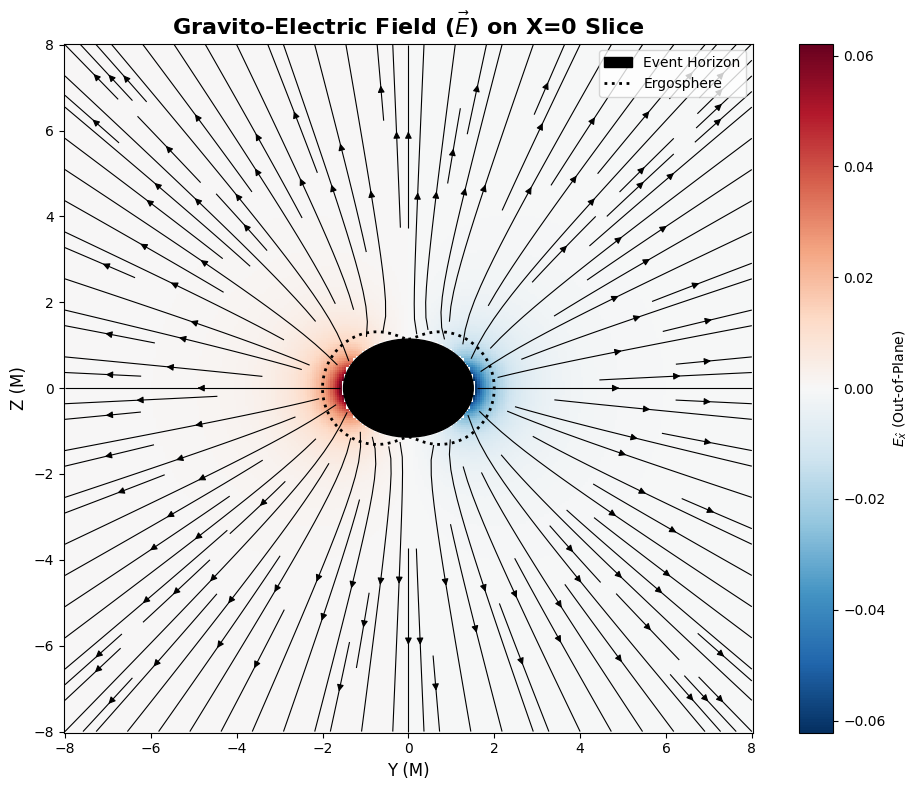

In [82]:
# ==========================================
# MODULE 1: GRAVITO-ELECTRIC FIELD ANALYSIS
# ==========================================

SLICE_PLANE = 'X' # Change to 'X', 'Y', or 'Z' to slice the Cartesian geometry

# 1. Define physics parameters
m_val = 1.0   
q_val = 0.8   
a_val = 0.99  
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

# 2. Determine Horizon and Route to the specialized E-field plotter
if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None # Cosmological
    else: horizon_r = m_val / 2.0
    
        
    plot_electric_field_cartesian(E_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_electric_field_spherical(E_hat, r, theta, param_dict, horizon_radius=horizon_r)

In [40]:
def plot_magnetic_field_cartesian(B_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Gravito-Magnetic Field (B) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    # 1. Dynamically configure the slice plane
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_idx, v_idx, out_idx = 1, 3, 2  
        h_label, v_label = "X (M)", "Z (M)"
        out_str = "y"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_idx, v_idx, out_idx = 2, 3, 1  
        h_label, v_label = "Y (M)", "Z (M)"
        out_str = "x"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_idx, v_idx, out_idx = 1, 2, 3  
        h_label, v_label = "X (M)", "Y (M)"
        out_str = "z"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    # --- AUTO-DETECTOR: Scan for the row with the most active components ---
    best_row = 0
    max_activity = -1
    
    for r_idx in range(4):
        expr_h = B_hat[r_idx, h_idx].subs(full_subs, simultaneous=True).doit()
        expr_v = B_hat[r_idx, v_idx].subs(full_subs, simultaneous=True).doit()
        expr_o = B_hat[r_idx, out_idx].subs(full_subs, simultaneous=True).doit()
        
        activity = (1 if expr_h != 0 else 0) + (1 if expr_v != 0 else 0) + (1 if expr_o != 0 else 0)
        if activity > max_activity:
            max_activity = activity
            best_row = r_idx

    row_labels = ['0', 'x', 'y', 'z']
    active_row = row_labels[best_row]
    print(f"\n--- AUTO-DETECTOR ---")
    print(f"Scanned 4x4 Matrix. Locked onto Row {best_row} (B_{{{active_row}j}}) with {max_activity} active components.")
    print("---------------------\n")

    out_title = fr"$B_{{{active_row}{out_str}}}$ (Out-of-Plane)"

    # 2. Extract and compile using the auto-detected row
    B_h_expr = B_hat[best_row, h_idx].subs(full_subs, simultaneous=True).doit()
    B_v_expr = B_hat[best_row, v_idx].subs(full_subs, simultaneous=True).doit()
    B_out_expr = B_hat[best_row, out_idx].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    B_h_func = lambdify((h_sym, v_sym), B_h_expr, "numpy", cse=True)
    B_v_func = lambdify((h_sym, v_sym), B_v_expr, "numpy", cse=True)
    B_out_func = lambdify((h_sym, v_sym), B_out_expr, "numpy", cse=True)

    # 3. Evaluate Grid
    grid_lim = 8.0
    res = 300
    h_vals = np.linspace(-grid_lim, grid_lim, res)
    v_vals = np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    
    # --- FIX: Define R globally for array sizing BEFORE the mask logic ---
    R = np.sqrt(H_grid**2 + V_grid**2)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), 1.0)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)
    
    if hr > 0 and abs(a_val) > 0 and slice_axis != 'Z':
        # Elliptical mask for highly spinning black holes in Cartesian coordinates
        R_ellipse = np.sqrt((H_grid**2) * (hr**2) / (hr**2 + a_val**2) + V_grid**2)
        mask = R_ellipse > (1.02 * hr)
    else:
        mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
        
    H_safe = np.where(mask, H_grid, 1.02 * hr)
    V_safe = np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    B_h_num = np.zeros_like(R)
    B_v_num = np.zeros_like(R)
    B_out_num = np.zeros_like(R)

    B_h_num[mask] = safe_eval(B_h_func, H_safe[mask], V_safe[mask])
    B_v_num[mask] = safe_eval(B_v_func, H_safe[mask], V_safe[mask])
    B_out_num[mask] = safe_eval(B_out_func, H_safe[mask], V_safe[mask])

    B_h_num[~mask], B_v_num[~mask], B_out_num[~mask] = np.nan, np.nan, np.nan

    # 4. Render Deep-Dive Plot
    print("Rendering Magnetic Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    out_max = np.nanmax(np.abs(B_out_num))
    if np.isnan(out_max) or out_max == 0: out_max = 1.0
    
    cmap = ax.pcolormesh(H_grid, V_grid, B_out_num, shading='auto', cmap='RdBu_r', vmin=-out_max, vmax=out_max)
    fig.colorbar(cmap, ax=ax, label=out_title)
    
    if np.any(B_h_num[mask] != 0) or np.any(B_v_num[mask] != 0):
        ax.streamplot(h_vals, v_vals, B_h_num, B_v_num, color='black', density=1.5, linewidth=0.8)
        
    
    # --- ADDED: ELLIPTICAL EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    if hr > 0:
        if abs(a_val) > 0 and slice_axis != 'Z':
            # Oblate Ellipse for the true physical shape of the spinning horizon
            width = 2 * np.sqrt(hr**2 + a_val**2)
            height = 2 * hr
            ax.add_patch(Ellipse((0, 0), width, height, color='black', zorder=10, label='Event Horizon'))
        else:
            ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

    if m_val is not None and abs(a_val) > 0.0:
        theta_ergo = np.linspace(0, 2 * np.pi, 200)
        if slice_axis == 'Z':
            ax.add_patch(plt.Circle((0, 0), 2 * m_val, fill=False, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere'))
        else:
            r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
            h_ergo = r_ergo * np.sin(theta_ergo) 
            v_ergo = r_ergo * np.cos(theta_ergo) 
            ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')
            
    if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
        ax.legend(loc='upper right')
    # -------------------------------------------------------------
    ax.set_aspect('equal')
    ax.set_title(rf"Gravito-Magnetic Field ($\vec{{B}}$) on {slice_axis}=0 Slice", fontsize=16, fontweight='bold')
    ax.set_xlabel(h_label, fontsize=12)
    ax.set_ylabel(v_label, fontsize=12)

    plt.tight_layout()
    plt.show()

def plot_magnetic_field_spherical(B_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Gravito-Magnetic Field (B) on the r-theta plane...")
    
    # --- AUTO-DETECTOR: Scan for the row with the most active components ---
    best_row = 0
    max_activity = -1
    
    for r_idx in range(4):
        expr_r = B_hat[r_idx, 1].subs(param_dict, simultaneous=True).doit()
        expr_t = B_hat[r_idx, 2].subs(param_dict, simultaneous=True).doit()
        expr_p = B_hat[r_idx, 3].subs(param_dict, simultaneous=True).doit()
        
        activity = (1 if expr_r != 0 else 0) + (1 if expr_t != 0 else 0) + (1 if expr_p != 0 else 0)
        if activity > max_activity:
            max_activity = activity
            best_row = r_idx

    row_labels = ['0', 'r', r'\theta', r'\phi']
    active_row = row_labels[best_row]
    print(f"\n--- AUTO-DETECTOR ---")
    print(f"Scanned 4x4 Matrix. Locked onto Row {best_row} (B_{{{active_row}j}}) with {max_activity} active components.")
    print("---------------------\n")

    out_title = fr"$B_{{{active_row}\phi}}$ (Out-of-Plane)"

    # Extract and compile using the auto-detected row!
    B_r_expr = B_hat[best_row, 1].subs(param_dict, simultaneous=True).doit()
    B_t_expr = B_hat[best_row, 2].subs(param_dict, simultaneous=True).doit()
    B_p_expr = B_hat[best_row, 3].subs(param_dict, simultaneous=True).doit() 
    
    print("Compiling AST to C-code (CSE Activated)...")
    B_r_func = lambdify((r_sym, theta_sym), B_r_expr, "numpy", cse=True)
    B_t_func = lambdify((r_sym, theta_sym), B_t_expr, "numpy", cse=True)
    B_p_func = lambdify((r_sym, theta_sym), B_p_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals = np.linspace(-grid_lim, grid_lim, res)
    z_vals = np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe = np.where(mask, R, 1.02 * hr)
    Theta_safe = np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    B_r_num = np.zeros_like(R)
    B_t_num = np.zeros_like(R)
    B_p_num = np.zeros_like(R)
    
    B_r_num[mask] = safe_eval(B_r_func, R_safe[mask], Theta_safe[mask])
    B_t_num[mask] = safe_eval(B_t_func, R_safe[mask], Theta_safe[mask])
    B_p_num[mask] = safe_eval(B_p_func, R_safe[mask], Theta_safe[mask])
    
    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    # Correct Spherical to Cartesian projection for the streamlines
    B_x_num = (B_r_num * np.sin(Theta) + B_t_num * np.cos(Theta)) * sign_x
    B_z_num = B_r_num * np.cos(Theta) - B_t_num * np.sin(Theta)
    
    B_x_num[~mask], B_z_num[~mask], B_p_num[~mask] = np.nan, np.nan, np.nan

    print("Rendering Magnetic Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    p_max = np.nanmax(np.abs(B_p_num))
    if np.isnan(p_max) or p_max == 0: p_max = 1.0
    
    cmap = ax.pcolormesh(X, Z, B_p_num, shading='auto', cmap='RdBu_r', vmin=-p_max, vmax=p_max)
    fig.colorbar(cmap, ax=ax, label=out_title)
    
    if np.any(B_x_num[mask] != 0) or np.any(B_z_num[mask] != 0):
        ax.streamplot(x_vals, z_vals, B_x_num, B_z_num, color='black', density=1.5, linewidth=0.8)
        
    
    # --- ADDED: ERGOSPHERE OVERLAY ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    # --- ADDED: EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    if hr > 0:
        ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

    if m_val is not None and abs(a_val) > 0.0:
        theta_ergo = np.linspace(0, 2 * np.pi, 200)
        
        # Spherical plotter is always the Meridional Slice: Pumpkin shape
        r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
        
        # X-Z plane mapping
        h_ergo = r_ergo * np.sin(theta_ergo) 
        v_ergo = r_ergo * np.cos(theta_ergo) 
        
        ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')

    if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
        ax.legend(loc='upper right')
    # --------------------------------------------------
    ax.set_aspect('equal')
    ax.set_title(rf"Gravito-Magnetic Field ($\vec{{B}}$) on Meridional Plane", fontsize=16, fontweight='bold')
    ax.set_xlabel("X (M)", fontsize=12)
    ax.set_ylabel("Z (M)", fontsize=12)

    plt.tight_layout()
    plt.show()

Rigorous Analysis: Gravito-Magnetic Field (B) on the Y=0 plane...

--- AUTO-DETECTOR ---
Scanned 4x4 Matrix. Locked onto Row 1 (B_{xj}) with 3 active components.
---------------------

Compiling AST to C-code (CSE Activated)...
Rendering Magnetic Field Slice...


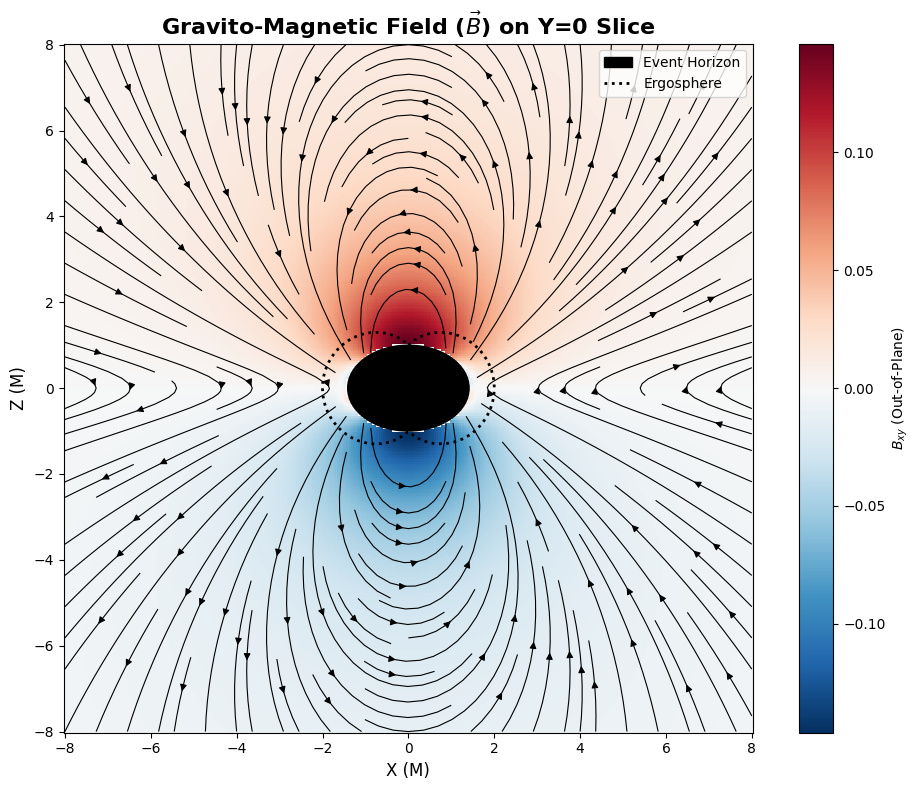

In [83]:
# ==========================================
# MODULE 2: GRAVITO-MAGNETIC FIELD ANALYSIS
# ==========================================

SLICE_PLANE = 'Y' # Slice the Cartesian geometry (X, Y, or Z)

# 1. Define physics parameters
m_val = 1.0   
q_val = 0.8   
a_val = 0.99999999   # Kerr Spin parameter (Crucial for B-field generation!)
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

# 2. Determine Horizon and Route to the specialized B-field plotter
if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None # Cosmological
    else: horizon_r = m_val / 2.0
        
    plot_magnetic_field_cartesian(B_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_magnetic_field_spherical(B_hat, r, theta, param_dict, horizon_radius=horizon_r)

In [30]:
def plot_D_field_cartesian(D_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Macroscopic Electric Field (D) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    # 1. Dynamically configure the slice plane
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_idx, v_idx, out_idx = 1, 3, 2  
        h_label, v_label = "X (M)", "Z (M)"
        out_str = "y"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_idx, v_idx, out_idx = 2, 3, 1  
        h_label, v_label = "Y (M)", "Z (M)"
        out_str = "x"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_idx, v_idx, out_idx = 1, 2, 3  
        h_label, v_label = "X (M)", "Y (M)"
        out_str = "z"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    # --- AUTO-DETECTOR: Scan for the row with the most active components ---
    best_row = 0
    max_activity = -1
    
    for r_idx in range(4):
        expr_h = D_hat[r_idx, h_idx].subs(full_subs, simultaneous=True).doit()
        expr_v = D_hat[r_idx, v_idx].subs(full_subs, simultaneous=True).doit()
        expr_o = D_hat[r_idx, out_idx].subs(full_subs, simultaneous=True).doit()
        
        activity = (1 if expr_h != 0 else 0) + (1 if expr_v != 0 else 0) + (1 if expr_o != 0 else 0)
        if activity > max_activity:
            max_activity = activity
            best_row = r_idx

    row_labels = ['0', 'x', 'y', 'z']
    active_row = row_labels[best_row]
    print(f"\n--- AUTO-DETECTOR ---")
    print(f"Scanned 4x4 Matrix. Locked onto Row {best_row} (D_{{{active_row}j}}) with {max_activity} active components.")
    print("---------------------\n")

    out_title = fr"$D_{{{active_row}{out_str}}}$ (Out-of-Plane)"

    # 2. Extract and compile using the auto-detected row
    D_h_expr = D_hat[best_row, h_idx].subs(full_subs, simultaneous=True).doit()
    D_v_expr = D_hat[best_row, v_idx].subs(full_subs, simultaneous=True).doit()
    D_out_expr = D_hat[best_row, out_idx].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    D_h_func = lambdify((h_sym, v_sym), D_h_expr, "numpy", cse=True)
    D_v_func = lambdify((h_sym, v_sym), D_v_expr, "numpy", cse=True)
    D_out_func = lambdify((h_sym, v_sym), D_out_expr, "numpy", cse=True)

    # 3. Evaluate Grid
    grid_lim = 8.0
    res = 300
    h_vals = np.linspace(-grid_lim, grid_lim, res)
    v_vals = np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    
    # --- FIX: Define R globally for array sizing BEFORE the mask logic ---
    R = np.sqrt(H_grid**2 + V_grid**2)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), 1.0)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)
    
    if hr > 0 and abs(a_val) > 0 and slice_axis != 'Z':
        # Elliptical mask for highly spinning black holes in Cartesian coordinates
        R_ellipse = np.sqrt((H_grid**2) * (hr**2) / (hr**2 + a_val**2) + V_grid**2)
        mask = R_ellipse > (1.02 * hr)
    else:
        mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
        
    H_safe = np.where(mask, H_grid, 1.02 * hr)
    V_safe = np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    D_h_num = np.zeros_like(R)
    D_v_num = np.zeros_like(R)
    D_out_num = np.zeros_like(R)

    D_h_num[mask] = safe_eval(D_h_func, H_safe[mask], V_safe[mask])
    D_v_num[mask] = safe_eval(D_v_func, H_safe[mask], V_safe[mask])
    D_out_num[mask] = safe_eval(D_out_func, H_safe[mask], V_safe[mask])

    D_h_num[~mask], D_v_num[~mask], D_out_num[~mask] = np.nan, np.nan, np.nan

    # --- AUTO-DETECTION DIAGNOSTICS ---
    has_h = np.any(np.abs(D_h_num[mask]) > 1e-12)
    has_v = np.any(np.abs(D_v_num[mask]) > 1e-12)
    has_out = np.any(np.abs(D_out_num[mask]) > 1e-12)
    
    print(f"Horizontal In-Plane Component: {'ACTIVE' if has_h else 'ZERO'}")
    print(f"Vertical In-Plane Component:   {'ACTIVE' if has_v else 'ZERO'}")
    print(f"Out-of-Plane Component:        {'ACTIVE' if has_out else 'ZERO'}")
    print("----------------------------\n")

    # 4. Render Deep-Dive Plot
    print("Rendering D Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    out_max = np.nanmax(np.abs(D_out_num))
    if np.isnan(out_max) or out_max == 0: out_max = 1.0
    
    cmap = ax.pcolormesh(H_grid, V_grid, D_out_num, shading='auto', cmap='RdBu_r', vmin=-out_max, vmax=out_max)
    fig.colorbar(cmap, ax=ax, label=out_title)
    
    if has_h or has_v:
        ax.streamplot(h_vals, v_vals, D_h_num, D_v_num, color='black', density=1.5, linewidth=0.8)
        
    # --- ADDED: ELLIPTICAL EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    if hr > 0:
        if abs(a_val) > 0 and slice_axis != 'Z':
            # Oblate Ellipse for the true physical shape of the spinning horizon
            width = 2 * np.sqrt(hr**2 + a_val**2)
            height = 2 * hr
            ax.add_patch(Ellipse((0, 0), width, height, color='black', zorder=10, label='Event Horizon'))
        else:
            ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

    if m_val is not None and abs(a_val) > 0.0:
        theta_ergo = np.linspace(0, 2 * np.pi, 200)
        if slice_axis == 'Z':
            ax.add_patch(plt.Circle((0, 0), 2 * m_val, fill=False, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere'))
        else:
            r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
            h_ergo = r_ergo * np.sin(theta_ergo) 
            v_ergo = r_ergo * np.cos(theta_ergo) 
            ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')
            
    if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
        ax.legend(loc='upper right')
    # -------------------------------------------------------------
    ax.set_aspect('equal')
    ax.set_title(rf"Macroscopic Electric Field ($\vec{{D}}$) on {slice_axis}=0 Slice", fontsize=16, fontweight='bold')
    ax.set_xlabel(h_label, fontsize=12)
    ax.set_ylabel(v_label, fontsize=12)

    plt.tight_layout()
    plt.show()

def plot_D_field_spherical(D_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Macroscopic Electric Field (D) on the r-theta plane...")
    
    # --- AUTO-DETECTOR: Scan for the row with the most active components ---
    best_row = 0
    max_activity = -1
    
    for r_idx in range(4):
        expr_r = D_hat[r_idx, 1].subs(param_dict, simultaneous=True).doit()
        expr_t = D_hat[r_idx, 2].subs(param_dict, simultaneous=True).doit()
        expr_p = D_hat[r_idx, 3].subs(param_dict, simultaneous=True).doit()
        
        activity = (1 if expr_r != 0 else 0) + (1 if expr_t != 0 else 0) + (1 if expr_p != 0 else 0)
        if activity > max_activity:
            max_activity = activity
            best_row = r_idx

    row_labels = ['0', 'r', r'\theta', r'\phi']
    active_row = row_labels[best_row]
    print(f"\n--- AUTO-DETECTOR ---")
    print(f"Scanned 4x4 Matrix. Locked onto Row {best_row} (D_{{{active_row}j}}) with {max_activity} active components.")
    print("---------------------\n")

    out_title = fr"$D_{{{active_row}\phi}}$ (Out-of-Plane)"

    # Extract and compile using the auto-detected row!
    D_r_expr = D_hat[best_row, 1].subs(param_dict, simultaneous=True).doit()
    D_t_expr = D_hat[best_row, 2].subs(param_dict, simultaneous=True).doit()
    D_p_expr = D_hat[best_row, 3].subs(param_dict, simultaneous=True).doit() 
    
    print("Compiling AST to C-code (CSE Activated)...")
    D_r_func = lambdify((r_sym, theta_sym), D_r_expr, "numpy", cse=True)
    D_t_func = lambdify((r_sym, theta_sym), D_t_expr, "numpy", cse=True)
    D_p_func = lambdify((r_sym, theta_sym), D_p_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals = np.linspace(-grid_lim, grid_lim, res)
    z_vals = np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe = np.where(mask, R, 1.02 * hr)
    Theta_safe = np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    D_r_num = np.zeros_like(R)
    D_t_num = np.zeros_like(R)
    D_p_num = np.zeros_like(R)
    
    D_r_num[mask] = safe_eval(D_r_func, R_safe[mask], Theta_safe[mask])
    D_t_num[mask] = safe_eval(D_t_func, R_safe[mask], Theta_safe[mask])
    D_p_num[mask] = safe_eval(D_p_func, R_safe[mask], Theta_safe[mask])
    
    # --- AUTO-DETECTION DIAGNOSTICS ---
    has_r = np.any(np.abs(D_r_num[mask]) > 1e-12)
    has_t = np.any(np.abs(D_t_num[mask]) > 1e-12)
    has_p = np.any(np.abs(D_p_num[mask]) > 1e-12)
    
    print(f"Radial Component (r):       {'ACTIVE' if has_r else 'ZERO'}")
    print(f"Polar Component (theta):    {'ACTIVE' if has_t else 'ZERO'}")
    print(f"Azimuthal Component (phi):  {'ACTIVE' if has_p else 'ZERO'}")
    print("----------------------------\n")

    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    # Correct Spherical to Cartesian projection for the streamlines
    D_x_num = (D_r_num * np.sin(Theta) + D_t_num * np.cos(Theta)) * sign_x
    D_z_num = D_r_num * np.cos(Theta) - D_t_num * np.sin(Theta)
    
    D_x_num[~mask], D_z_num[~mask], D_p_num[~mask] = np.nan, np.nan, np.nan

    print("Rendering D Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    p_max = np.nanmax(np.abs(D_p_num))
    if np.isnan(p_max) or p_max == 0: p_max = 1.0
    
    cmap = ax.pcolormesh(X, Z, D_p_num, shading='auto', cmap='RdBu_r', vmin=-p_max, vmax=p_max)
    fig.colorbar(cmap, ax=ax, label=out_title)
    
    if has_r or has_t:
        ax.streamplot(x_vals, z_vals, D_x_num, D_z_num, color='black', density=1.5, linewidth=0.8)
        
    # --- ADDED: EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    if hr > 0:
        ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

    if m_val is not None and abs(a_val) > 0.0:
        theta_ergo = np.linspace(0, 2 * np.pi, 200)
        
        # Spherical plotter is always the Meridional Slice: Pumpkin shape
        r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
        
        # X-Z plane mapping
        h_ergo = r_ergo * np.sin(theta_ergo) 
        v_ergo = r_ergo * np.cos(theta_ergo) 
        
        ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')

    if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
        ax.legend(loc='upper right')
    # --------------------------------------------------
    ax.set_aspect('equal')
    ax.set_title(rf"Macroscopic Electric Field ($\vec{{D}}$) on Meridional Plane", fontsize=16, fontweight='bold')
    ax.set_xlabel("X (M)", fontsize=12)
    ax.set_ylabel("Z (M)", fontsize=12)

    plt.tight_layout()
    plt.show()

Rigorous Analysis: Macroscopic Electric Field (D) on the Y=0 plane...

--- AUTO-DETECTOR ---
Scanned 4x4 Matrix. Locked onto Row 0 (D_{0j}) with 3 active components.
---------------------

Compiling AST to C-code (CSE Activated)...
Horizontal In-Plane Component: ACTIVE
Vertical In-Plane Component:   ACTIVE
Out-of-Plane Component:        ACTIVE
----------------------------

Rendering D Field Slice...


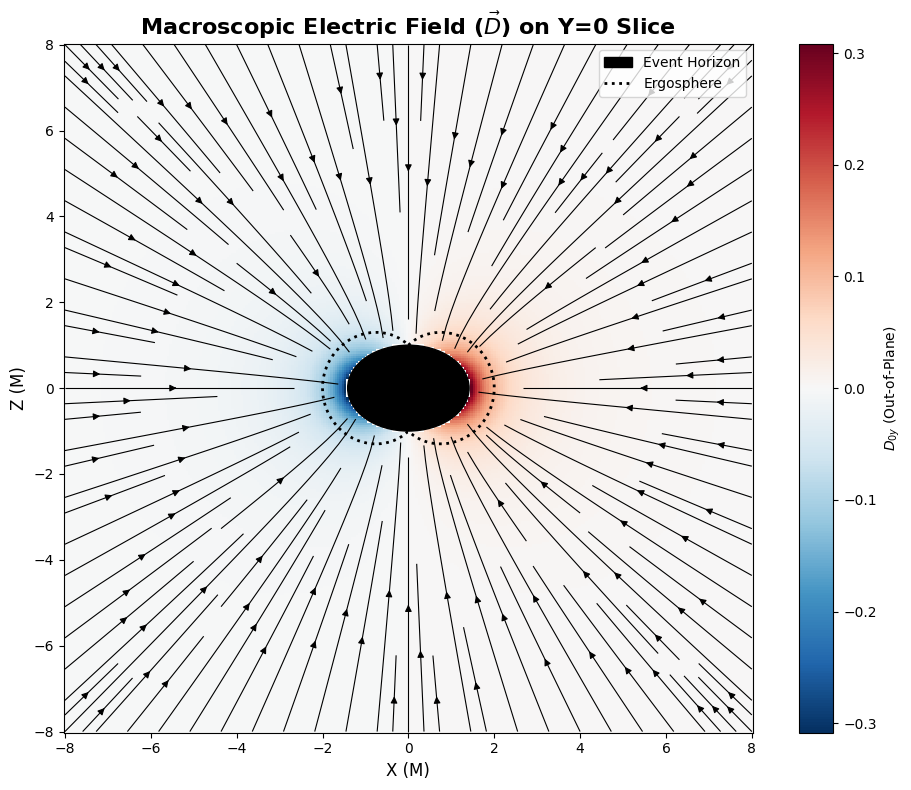

In [84]:
# ==========================================
# MODULE 3: MACROSCOPIC ELECTRIC FIELD (D) ANALYSIS
# ==========================================

SLICE_PLANE = 'Y' # Slice the Cartesian geometry (X, Y, or Z)

m_val = 1.0   
q_val = 0.8   
a_val = 0.99999999   
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None 
    else: horizon_r = m_val / 2.0
        
    plot_D_field_cartesian(D_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_D_field_spherical(D_hat, r, theta, param_dict, horizon_radius=horizon_r)

In [32]:
def plot_H_field_cartesian(H_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Macroscopic Magnetic Field (H) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    # 1. Dynamically configure the slice plane
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_idx, v_idx, out_idx = 1, 3, 2  
        h_label, v_label = "X (M)", "Z (M)"
        out_str = "y"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_idx, v_idx, out_idx = 2, 3, 1  
        h_label, v_label = "Y (M)", "Z (M)"
        out_str = "x"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_idx, v_idx, out_idx = 1, 2, 3  
        h_label, v_label = "X (M)", "Y (M)"
        out_str = "z"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    # --- AUTO-DETECTOR: Scan for the row with the most active components ---
    best_row = 0
    max_activity = -1
    
    for r_idx in range(4):
        expr_h = H_hat[r_idx, h_idx].subs(full_subs, simultaneous=True).doit()
        expr_v = H_hat[r_idx, v_idx].subs(full_subs, simultaneous=True).doit()
        expr_o = H_hat[r_idx, out_idx].subs(full_subs, simultaneous=True).doit()
        
        activity = (1 if expr_h != 0 else 0) + (1 if expr_v != 0 else 0) + (1 if expr_o != 0 else 0)
        if activity > max_activity:
            max_activity = activity
            best_row = r_idx

    row_labels = ['0', 'x', 'y', 'z']
    active_row = row_labels[best_row]
    print(f"\n--- AUTO-DETECTOR ---")
    print(f"Scanned 4x4 Matrix. Locked onto Row {best_row} (H_{{{active_row}j}}) with {max_activity} active components.")
    print("---------------------\n")

    out_title = fr"$H_{{{active_row}{out_str}}}$ (Out-of-Plane)"

    # 2. Extract and compile using the auto-detected row
    H_h_expr = H_hat[best_row, h_idx].subs(full_subs, simultaneous=True).doit()
    H_v_expr = H_hat[best_row, v_idx].subs(full_subs, simultaneous=True).doit()
    H_out_expr = H_hat[best_row, out_idx].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    H_h_func = lambdify((h_sym, v_sym), H_h_expr, "numpy", cse=True)
    H_v_func = lambdify((h_sym, v_sym), H_v_expr, "numpy", cse=True)
    H_out_func = lambdify((h_sym, v_sym), H_out_expr, "numpy", cse=True)

    # 3. Evaluate Grid
    grid_lim = 8.0
    res = 300
    h_vals = np.linspace(-grid_lim, grid_lim, res)
    v_vals = np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    
    # --- FIX: Define R globally for array sizing BEFORE the mask logic ---
    R = np.sqrt(H_grid**2 + V_grid**2)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), 1.0)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)
    
    if hr > 0 and abs(a_val) > 0 and slice_axis != 'Z':
        # Elliptical mask for highly spinning black holes in Cartesian coordinates
        R_ellipse = np.sqrt((H_grid**2) * (hr**2) / (hr**2 + a_val**2) + V_grid**2)
        mask = R_ellipse > (1.02 * hr)
    else:
        mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
        
    H_safe = np.where(mask, H_grid, 1.02 * hr)
    V_safe = np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    H_h_num = np.zeros_like(R)
    H_v_num = np.zeros_like(R)
    H_out_num = np.zeros_like(R)

    H_h_num[mask] = safe_eval(H_h_func, H_safe[mask], V_safe[mask])
    H_v_num[mask] = safe_eval(H_v_func, H_safe[mask], V_safe[mask])
    H_out_num[mask] = safe_eval(H_out_func, H_safe[mask], V_safe[mask])

    H_h_num[~mask], H_v_num[~mask], H_out_num[~mask] = np.nan, np.nan, np.nan

    # --- AUTO-DETECTION DIAGNOSTICS ---
    has_h = np.any(np.abs(H_h_num[mask]) > 1e-12)
    has_v = np.any(np.abs(H_v_num[mask]) > 1e-12)
    has_out = np.any(np.abs(H_out_num[mask]) > 1e-12)
    
    print(f"Horizontal In-Plane Component: {'ACTIVE' if has_h else 'ZERO'}")
    print(f"Vertical In-Plane Component:   {'ACTIVE' if has_v else 'ZERO'}")
    print(f"Out-of-Plane Component:        {'ACTIVE' if has_out else 'ZERO'}")
    print("----------------------------\n")

    # 4. Render Deep-Dive Plot
    print("Rendering H Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    out_max = np.nanmax(np.abs(H_out_num))
    if np.isnan(out_max) or out_max == 0: out_max = 1.0
    
    cmap = ax.pcolormesh(H_grid, V_grid, H_out_num, shading='auto', cmap='RdBu_r', vmin=-out_max, vmax=out_max)
    fig.colorbar(cmap, ax=ax, label=out_title)
    
    if has_h or has_v:
        ax.streamplot(h_vals, v_vals, H_h_num, H_v_num, color='black', density=1.5, linewidth=0.8)
        
    # --- ADDED: ELLIPTICAL EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    if hr > 0:
        if abs(a_val) > 0 and slice_axis != 'Z':
            # Oblate Ellipse for the true physical shape of the spinning horizon
            width = 2 * np.sqrt(hr**2 + a_val**2)
            height = 2 * hr
            ax.add_patch(Ellipse((0, 0), width, height, color='black', zorder=10, label='Event Horizon'))
        else:
            ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

    if m_val is not None and abs(a_val) > 0.0:
        theta_ergo = np.linspace(0, 2 * np.pi, 200)
        if slice_axis == 'Z':
            ax.add_patch(plt.Circle((0, 0), 2 * m_val, fill=False, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere'))
        else:
            r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
            h_ergo = r_ergo * np.sin(theta_ergo) 
            v_ergo = r_ergo * np.cos(theta_ergo) 
            ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')
            
    if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
        ax.legend(loc='upper right')
    # -------------------------------------------------------------
    ax.set_aspect('equal')
    ax.set_title(rf"Macroscopic Magnetic Field ($\vec{{H}}$) on {slice_axis}=0 Slice", fontsize=16, fontweight='bold')
    ax.set_xlabel(h_label, fontsize=12)
    ax.set_ylabel(v_label, fontsize=12)

    plt.tight_layout()
    plt.show()

def plot_H_field_spherical(H_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Macroscopic Magnetic Field (H) on the r-theta plane...")
    
    # --- AUTO-DETECTOR: Scan for the row with the most active components ---
    best_row = 0
    max_activity = -1
    
    for r_idx in range(4):
        expr_r = H_hat[r_idx, 1].subs(param_dict, simultaneous=True).doit()
        expr_t = H_hat[r_idx, 2].subs(param_dict, simultaneous=True).doit()
        expr_p = H_hat[r_idx, 3].subs(param_dict, simultaneous=True).doit()
        
        activity = (1 if expr_r != 0 else 0) + (1 if expr_t != 0 else 0) + (1 if expr_p != 0 else 0)
        if activity > max_activity:
            max_activity = activity
            best_row = r_idx

    row_labels = ['0', 'r', r'\theta', r'\phi']
    active_row = row_labels[best_row]
    print(f"\n--- AUTO-DETECTOR ---")
    print(f"Scanned 4x4 Matrix. Locked onto Row {best_row} (H_{{{active_row}j}}) with {max_activity} active components.")
    print("---------------------\n")

    out_title = fr"$H_{{{active_row}\phi}}$ (Out-of-Plane)"

    # Extract and compile using the auto-detected row!
    H_r_expr = H_hat[best_row, 1].subs(param_dict, simultaneous=True).doit()
    H_t_expr = H_hat[best_row, 2].subs(param_dict, simultaneous=True).doit()
    H_p_expr = H_hat[best_row, 3].subs(param_dict, simultaneous=True).doit() 
    
    print("Compiling AST to C-code (CSE Activated)...")
    H_r_func = lambdify((r_sym, theta_sym), H_r_expr, "numpy", cse=True)
    H_t_func = lambdify((r_sym, theta_sym), H_t_expr, "numpy", cse=True)
    H_p_func = lambdify((r_sym, theta_sym), H_p_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals = np.linspace(-grid_lim, grid_lim, res)
    z_vals = np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe = np.where(mask, R, 1.02 * hr)
    Theta_safe = np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    H_r_num = np.zeros_like(R)
    H_t_num = np.zeros_like(R)
    H_p_num = np.zeros_like(R)
    
    H_r_num[mask] = safe_eval(H_r_func, R_safe[mask], Theta_safe[mask])
    H_t_num[mask] = safe_eval(H_t_func, R_safe[mask], Theta_safe[mask])
    H_p_num[mask] = safe_eval(H_p_func, R_safe[mask], Theta_safe[mask])
    
    # --- AUTO-DETECTION DIAGNOSTICS ---
    has_r = np.any(np.abs(H_r_num[mask]) > 1e-12)
    has_t = np.any(np.abs(H_t_num[mask]) > 1e-12)
    has_p = np.any(np.abs(H_p_num[mask]) > 1e-12)
    
    print(f"Radial Component (r):       {'ACTIVE' if has_r else 'ZERO'}")
    print(f"Polar Component (theta):    {'ACTIVE' if has_t else 'ZERO'}")
    print(f"Azimuthal Component (phi):  {'ACTIVE' if has_p else 'ZERO'}")
    print("----------------------------\n")

    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    # Correct Spherical to Cartesian projection for the streamlines
    H_x_num = (H_r_num * np.sin(Theta) + H_t_num * np.cos(Theta)) * sign_x
    H_z_num = H_r_num * np.cos(Theta) - H_t_num * np.sin(Theta)
    
    H_x_num[~mask], H_z_num[~mask], H_p_num[~mask] = np.nan, np.nan, np.nan

    print("Rendering H Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    p_max = np.nanmax(np.abs(H_p_num))
    if np.isnan(p_max) or p_max == 0: p_max = 1.0
    
    cmap = ax.pcolormesh(X, Z, H_p_num, shading='auto', cmap='RdBu_r', vmin=-p_max, vmax=p_max)
    fig.colorbar(cmap, ax=ax, label=out_title)
    
    if has_r or has_t:
        ax.streamplot(x_vals, z_vals, H_x_num, H_z_num, color='black', density=1.5, linewidth=0.8)
        
    # --- ADDED: EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    if hr > 0:
        ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

    if m_val is not None and abs(a_val) > 0.0:
        theta_ergo = np.linspace(0, 2 * np.pi, 200)
        
        # Spherical plotter is always the Meridional Slice: Pumpkin shape
        r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
        
        # X-Z plane mapping
        h_ergo = r_ergo * np.sin(theta_ergo) 
        v_ergo = r_ergo * np.cos(theta_ergo) 
        
        ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')

    if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
        ax.legend(loc='upper right')
    # --------------------------------------------------
    ax.set_aspect('equal')
    ax.set_title(rf"Macroscopic Magnetic Field ($\vec{{H}}$) on Meridional Plane", fontsize=16, fontweight='bold')
    ax.set_xlabel("X (M)", fontsize=12)
    ax.set_ylabel("Z (M)", fontsize=12)

    plt.tight_layout()
    plt.show()

    

Rigorous Analysis: Macroscopic Magnetic Field (H) on the Y=0 plane...

--- AUTO-DETECTOR ---
Scanned 4x4 Matrix. Locked onto Row 0 (H_{0j}) with 3 active components.
---------------------

Compiling AST to C-code (CSE Activated)...
Horizontal In-Plane Component: ACTIVE
Vertical In-Plane Component:   ACTIVE
Out-of-Plane Component:        ACTIVE
----------------------------

Rendering H Field Slice...


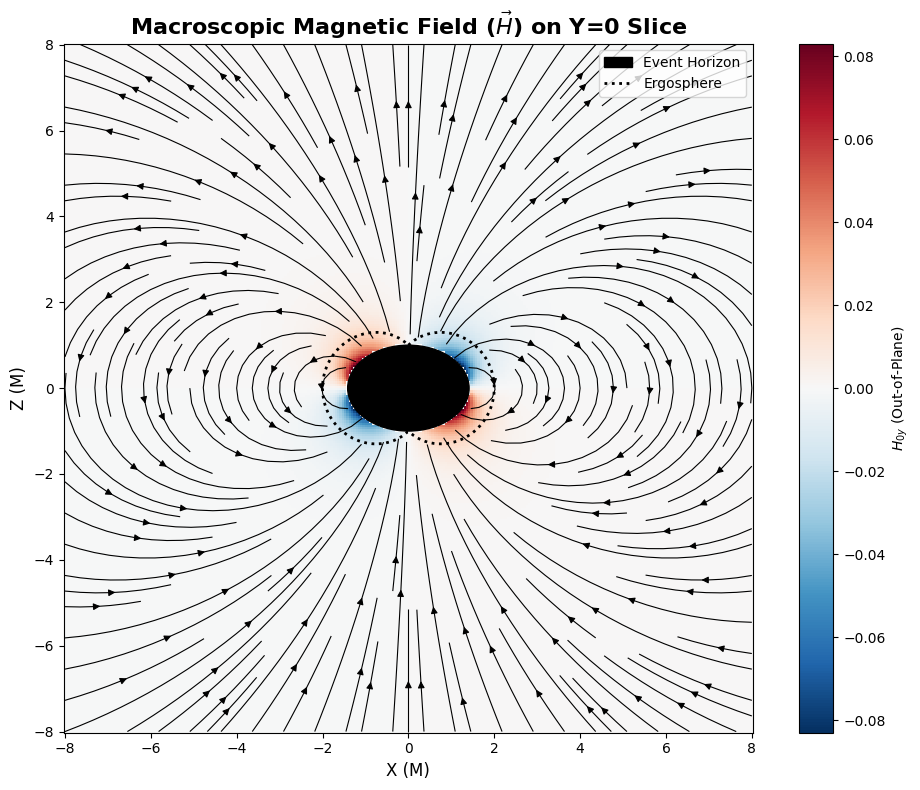

In [85]:
# ==========================================
# MODULE 4: MACROSCOPIC MAGNETIC FIELD (H) ANALYSIS
# ==========================================

SLICE_PLANE = 'Y' # Slice the Cartesian geometry (X, Y, or Z)

m_val = 1.0   
q_val = 0.8   
a_val = 0.999999999   
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None 
    else: horizon_r = m_val / 2.0
        
    plot_H_field_cartesian(H_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_H_field_spherical(H_hat, r, theta, param_dict, horizon_radius=horizon_r)

In [7]:
def plot_scalar_charges_cartesian(rho_hat, q_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Scalar Densities (\u03c1_0, q_0) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    # 1. Dynamically configure the slice plane
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_label, v_label = "X (M)", "Z (M)"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_label, v_label = "Y (M)", "Z (M)"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_label, v_label = "X (M)", "Y (M)"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    # 2. Extract and compile the 0-th (time) components
    rho0_expr = rho_hat[0].subs(full_subs, simultaneous=True).doit()
    q0_expr = q_hat[0].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    rho0_func = lambdify((h_sym, v_sym), rho0_expr, "numpy", cse=True)
    q0_func = lambdify((h_sym, v_sym), q0_expr, "numpy", cse=True)

    # 3. Evaluate Grid
    grid_lim = 8.0
    res = 300
    h_vals = np.linspace(-grid_lim, grid_lim, res)
    v_vals = np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    
    # --- FIX: Define R globally for array sizing BEFORE the mask logic ---
    R = np.sqrt(H_grid**2 + V_grid**2) 
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), 1.0)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)
    
    if hr > 0 and abs(a_val) > 0 and slice_axis != 'Z':
        # Elliptical mask for highly spinning black holes in Cartesian coordinates
        R_ellipse = np.sqrt((H_grid**2) * (hr**2) / (hr**2 + a_val**2) + V_grid**2)
        mask = R_ellipse > (1.02 * hr)
    else:
        # Spherical mask
        mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
        
    H_safe = np.where(mask, H_grid, 1.02 * hr)
    V_safe = np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    rho0_num = np.zeros_like(R)
    q0_num = np.zeros_like(R)

    rho0_num[mask] = safe_eval(rho0_func, H_safe[mask], V_safe[mask])
    q0_num[mask] = safe_eval(q0_func, H_safe[mask], V_safe[mask])

    rho0_num[~mask] = np.nan
    q0_num[~mask] = np.nan

    # --- AUTO-DETECTION DIAGNOSTICS ---
    print(f"\n--- SCALAR FIELD AUTO-DETECTION ---")
    print(f"Energy Density (\u03c1_0):   {'ACTIVE' if np.any(np.abs(rho0_num[mask]) > 1e-12) else 'ZERO'}")
    print(f"Macroscopic Charge (q_0): {'ACTIVE' if np.any(np.abs(q0_num[mask]) > 1e-12) else 'ZERO'}")
    print("-----------------------------------\n")

    # 4. Render Deep-Dive Plot
    print("Rendering Scalar Field Slices...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot rho_0
    ax1 = axes[0]
    rho_max = np.nanmax(np.abs(rho0_num))
    if np.isnan(rho_max) or rho_max == 0: rho_max = 1.0
    cmap1 = ax1.pcolormesh(H_grid, V_grid, rho0_num, shading='auto', cmap='RdBu_r', vmin=-rho_max, vmax=rho_max)
    fig.colorbar(cmap1, ax=ax1, label=r"Gravitational Energy Density ($\rho_{\hat{0}}$)")
    
    ax1.set_aspect('equal')
    ax1.set_title(rf"Energy Density ($\rho_{{\hat{{0}}}}$) on {slice_axis}=0 Slice", fontsize=15, fontweight='bold')
    ax1.set_xlabel(h_label, fontsize=12)
    ax1.set_ylabel(v_label, fontsize=12)

    # Plot q_0
    ax2 = axes[1]
    q_max = np.nanmax(np.abs(q0_num))
    if np.isnan(q_max) or q_max == 0: q_max = 1.0 
    cmap2 = ax2.pcolormesh(H_grid, V_grid, q0_num, shading='auto', cmap='RdBu_r', vmin=-q_max, vmax=q_max)
    fig.colorbar(cmap2, ax=ax2, label=r"Macroscopic Charge ($q_{\hat{0}}$)")

    ax2.set_aspect('equal')
    ax2.set_title(rf"Macroscopic Charge ($q_{{\hat{{0}}}}$) on {slice_axis}=0 Slice", fontsize=15, fontweight='bold')
    ax2.set_xlabel(h_label, fontsize=12)

    # --- ADDED: ELLIPTICAL EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    for ax in [ax1, ax2]:
        if hr > 0:
            if abs(a_val) > 0 and slice_axis != 'Z':
                # Oblate Ellipse for the true physical shape of the spinning horizon
                width = 2 * np.sqrt(hr**2 + a_val**2)
                height = 2 * hr
                ax.add_patch(Ellipse((0, 0), width, height, color='black', zorder=10, label='Event Horizon'))
            else:
                ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

        if m_val is not None and abs(a_val) > 0.0:
            theta_ergo = np.linspace(0, 2 * np.pi, 200)
            if slice_axis == 'Z':
                ax.add_patch(plt.Circle((0, 0), 2 * m_val, fill=False, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere'))
            else:
                r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
                h_ergo = r_ergo * np.sin(theta_ergo) 
                v_ergo = r_ergo * np.cos(theta_ergo) 
                ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')
                
        if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
            ax.legend(loc='upper right')
    # -------------------------------------------------------------

    plt.tight_layout()
    plt.show()

def plot_scalar_charges_spherical(rho_hat, q_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Scalar Densities (\u03c1_0, q_0) on the r-theta plane...")
    
    # 1. Extract and compile the 0-th (time) components
    rho0_expr = rho_hat[0].subs(param_dict, simultaneous=True).doit()
    q0_expr = q_hat[0].subs(param_dict, simultaneous=True).doit()
    
    print("Compiling AST to C-code (CSE Activated)...")
    rho0_func = lambdify((r_sym, theta_sym), rho0_expr, "numpy", cse=True)
    q0_func = lambdify((r_sym, theta_sym), q0_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals = np.linspace(-grid_lim, grid_lim, res)
    z_vals = np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe = np.where(mask, R, 1.02 * hr)
    Theta_safe = np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    rho0_num = np.zeros_like(R)
    q0_num = np.zeros_like(R)
    
    rho0_num[mask] = safe_eval(rho0_func, R_safe[mask], Theta_safe[mask])
    q0_num[mask] = safe_eval(q0_func, R_safe[mask], Theta_safe[mask])
    
    rho0_num[~mask] = np.nan
    q0_num[~mask] = np.nan
    
    # --- AUTO-DETECTION DIAGNOSTICS ---
    print(f"\n--- SCALAR FIELD AUTO-DETECTION ---")
    print(f"Energy Density (\u03c1_0):   {'ACTIVE' if np.any(np.abs(rho0_num[mask]) > 1e-12) else 'ZERO'}")
    print(f"Macroscopic Charge (q_0): {'ACTIVE' if np.any(np.abs(q0_num[mask]) > 1e-12) else 'ZERO'}")
    print("-----------------------------------\n")

    print("Rendering Scalar Field Slices...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot rho_0
    ax1 = axes[0]
    rho_max = np.nanmax(np.abs(rho0_num))
    if np.isnan(rho_max) or rho_max == 0: rho_max = 1.0
    cmap1 = ax1.pcolormesh(X, Z, rho0_num, shading='auto', cmap='RdBu_r', vmin=-rho_max, vmax=rho_max)
    fig.colorbar(cmap1, ax=ax1, label=r"Gravitational Energy Density ($\rho_{\hat{0}}$)")
    
    ax1.set_aspect('equal')
    ax1.set_title(r"Energy Density ($\rho_{\hat{0}}$) on Meridional Plane", fontsize=15, fontweight='bold')
    ax1.set_xlabel("X (M)", fontsize=12)
    ax1.set_ylabel("Z (M)", fontsize=12)

    # Plot q_0
    ax2 = axes[1]
    q_max = np.nanmax(np.abs(q0_num))
    if np.isnan(q_max) or q_max == 0: q_max = 1.0 
    cmap2 = ax2.pcolormesh(X, Z, q0_num, shading='auto', cmap='RdBu_r', vmin=-q_max, vmax=q_max)
    fig.colorbar(cmap2, ax=ax2, label=r"Macroscopic Charge ($q_{\hat{0}}$)")
    
    ax2.set_aspect('equal')
    ax2.set_title(r"Macroscopic Charge ($q_{\hat{0}}$) on Meridional Plane", fontsize=15, fontweight='bold')
    ax2.set_xlabel("X (M)", fontsize=12)

    # --- ADDED: EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    for ax in [ax1, ax2]:
        if hr > 0:
            ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

        if m_val is not None and abs(a_val) > 0.0:
            theta_ergo = np.linspace(0, 2 * np.pi, 200)
            r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
            
            # Map the spherical coordinates directly to the plot axes
            h_ergo = r_ergo * np.sin(theta_ergo) 
            v_ergo = r_ergo * np.cos(theta_ergo) 
            
            ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')

        if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
            ax.legend(loc='upper right')
    # --------------------------------------------------

    plt.tight_layout()
    plt.show()

Rigorous Analysis: Scalar Densities (ρ_0, q_0) on the X=0 plane...
Compiling AST to C-code (CSE Activated)...

--- SCALAR FIELD AUTO-DETECTION ---
Energy Density (ρ_0):   ACTIVE
Macroscopic Charge (q_0): ACTIVE
-----------------------------------

Rendering Scalar Field Slices...


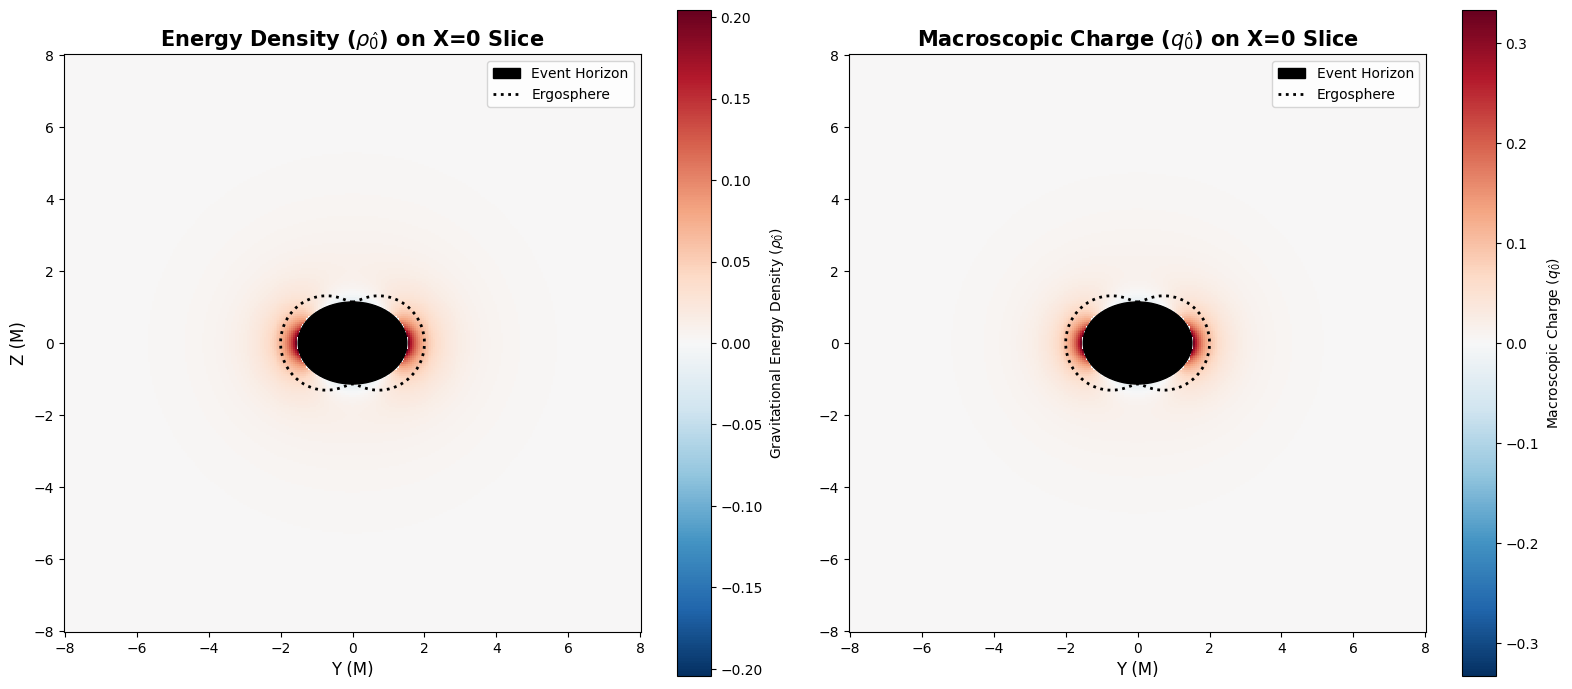

In [86]:
# ==========================================
# MODULE 5: SCALAR DENSITIES (rho_0, q_0)
# ==========================================

SLICE_PLANE = 'X' # Slice the Cartesian geometry (X, Y, or Z)

m_val = 1.0   
q_val = 0.8   
a_val = 0.99
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None 
    else: horizon_r = m_val / 2.0
        
    plot_scalar_charges_cartesian(rho_hat, q_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_scalar_charges_spherical(rho_hat, q_hat, r, theta, param_dict, horizon_radius=horizon_r)

In [11]:
def plot_spatial_currents_cartesian(rho_hat, q_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Spatial Currents (\u03c1_i, q_i) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_idx, v_idx, out_idx = 1, 3, 2  
        h_label, v_label = "X (M)", "Z (M)"
        out_str = "y"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_idx, v_idx, out_idx = 2, 3, 1  
        h_label, v_label = "Y (M)", "Z (M)"
        out_str = "x"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_idx, v_idx, out_idx = 1, 2, 3  
        h_label, v_label = "X (M)", "Y (M)"
        out_str = "z"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    # Extract components from the 1D arrays
    rho_h_expr = rho_hat[h_idx].subs(full_subs, simultaneous=True).doit()
    rho_v_expr = rho_hat[v_idx].subs(full_subs, simultaneous=True).doit()
    rho_out_expr = rho_hat[out_idx].subs(full_subs, simultaneous=True).doit()
    
    q_h_expr = q_hat[h_idx].subs(full_subs, simultaneous=True).doit()
    q_v_expr = q_hat[v_idx].subs(full_subs, simultaneous=True).doit()
    q_out_expr = q_hat[out_idx].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    rho_h_func = lambdify((h_sym, v_sym), rho_h_expr, "numpy", cse=True)
    rho_v_func = lambdify((h_sym, v_sym), rho_v_expr, "numpy", cse=True)
    rho_out_func = lambdify((h_sym, v_sym), rho_out_expr, "numpy", cse=True)
    
    q_h_func = lambdify((h_sym, v_sym), q_h_expr, "numpy", cse=True)
    q_v_func = lambdify((h_sym, v_sym), q_v_expr, "numpy", cse=True)
    q_out_func = lambdify((h_sym, v_sym), q_out_expr, "numpy", cse=True)

    grid_lim = 8.0
    res = 300
    h_vals = np.linspace(-grid_lim, grid_lim, res)
    v_vals = np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    
    # --- FIX: Define R globally for array sizing BEFORE the mask logic ---
    R = np.sqrt(H_grid**2 + V_grid**2) 
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), 1.0)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)
    
    if hr > 0 and abs(a_val) > 0 and slice_axis != 'Z':
        # Elliptical mask for highly spinning black holes in Cartesian coordinates
        R_ellipse = np.sqrt((H_grid**2) * (hr**2) / (hr**2 + a_val**2) + V_grid**2)
        mask = R_ellipse > (1.02 * hr)
    else:
        mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
        
    H_safe = np.where(mask, H_grid, 1.02 * hr)
    V_safe = np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    rho_h_num, rho_v_num, rho_out_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)
    q_h_num, q_v_num, q_out_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)

    rho_h_num[mask] = safe_eval(rho_h_func, H_safe[mask], V_safe[mask])
    rho_v_num[mask] = safe_eval(rho_v_func, H_safe[mask], V_safe[mask])
    rho_out_num[mask] = safe_eval(rho_out_func, H_safe[mask], V_safe[mask])
    
    q_h_num[mask] = safe_eval(q_h_func, H_safe[mask], V_safe[mask])
    q_v_num[mask] = safe_eval(q_v_func, H_safe[mask], V_safe[mask])
    q_out_num[mask] = safe_eval(q_out_func, H_safe[mask], V_safe[mask])

    for arr in [rho_h_num, rho_v_num, rho_out_num, q_h_num, q_v_num, q_out_num]:
        arr[~mask] = np.nan

    # --- AUTO-DETECTION DIAGNOSTICS ---
    print(f"\n--- SPATIAL VECTOR AUTO-DETECTION ---")
    print(f"Momentum (\u03c1_i) Active Components: In-Plane={'YES' if np.any(np.abs(rho_h_num[mask])+np.abs(rho_v_num[mask])>1e-12) else 'NO'}, Out-of-Plane={'YES' if np.any(np.abs(rho_out_num[mask])>1e-12) else 'NO'}")
    print(f"Charge (q_i) Active Components:   In-Plane={'YES' if np.any(np.abs(q_h_num[mask])+np.abs(q_v_num[mask])>1e-12) else 'NO'}, Out-of-Plane={'YES' if np.any(np.abs(q_out_num[mask])>1e-12) else 'NO'}")
    print("-------------------------------------\n")

    print("Rendering Spatial Currents...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot rho_i
    ax1 = axes[0]
    r_max = np.nanmax(np.abs(rho_out_num))
    if np.isnan(r_max) or r_max == 0: r_max = 1.0
    cmap1 = ax1.pcolormesh(H_grid, V_grid, rho_out_num, shading='auto', cmap='RdBu_r', vmin=-r_max, vmax=r_max)
    fig.colorbar(cmap1, ax=ax1, label=fr"$\rho_{{{out_str}}}$ (Out-of-Plane)")
    if np.any(np.abs(rho_h_num[mask])+np.abs(rho_v_num[mask]) > 1e-12):
        ax1.streamplot(h_vals, v_vals, rho_h_num, rho_v_num, color='black', density=1.5, linewidth=0.8)
    
    
    ax1.set_aspect('equal')
    ax1.set_title(rf"Momentum Density ($\vec{{\rho}}$) on {slice_axis}=0 Slice", fontsize=15, fontweight='bold')
    ax1.set_xlabel(h_label, fontsize=12)
    ax1.set_ylabel(v_label, fontsize=12)

    # Plot q_i
    ax2 = axes[1]
    q_max = np.nanmax(np.abs(q_out_num))
    if np.isnan(q_max) or q_max == 0: q_max = 1.0 
    cmap2 = ax2.pcolormesh(H_grid, V_grid, q_out_num, shading='auto', cmap='RdBu_r', vmin=-q_max, vmax=q_max)
    fig.colorbar(cmap2, ax=ax2, label=fr"$q_{{{out_str}}}$ (Out-of-Plane)")
    if np.any(np.abs(q_h_num[mask])+np.abs(q_v_num[mask]) > 1e-12):
        ax2.streamplot(h_vals, v_vals, q_h_num, q_v_num, color='black', density=1.5, linewidth=0.8)
    
    ax2.set_aspect('equal')
    ax2.set_title(rf"Spatial Charge Current ($\vec{{q}}$) on {slice_axis}=0 Slice", fontsize=15, fontweight='bold')
    ax2.set_xlabel(h_label, fontsize=12)

    # --- ADDED: ELLIPTICAL EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    for ax in [ax1, ax2]:
        if hr > 0:
            if abs(a_val) > 0 and slice_axis != 'Z':
                # Oblate Ellipse for the true physical shape of the spinning horizon
                width = 2 * np.sqrt(hr**2 + a_val**2)
                height = 2 * hr
                ax.add_patch(Ellipse((0, 0), width, height, color='black', zorder=10, label='Event Horizon'))
            else:
                ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

        if m_val is not None and abs(a_val) > 0.0:
            theta_ergo = np.linspace(0, 2 * np.pi, 200)
            if slice_axis == 'Z':
                ax.add_patch(plt.Circle((0, 0), 2 * m_val, fill=False, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere'))
            else:
                r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
                h_ergo = r_ergo * np.sin(theta_ergo) 
                v_ergo = r_ergo * np.cos(theta_ergo) 
                ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')
                
        if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
            ax.legend(loc='upper right')
    # -------------------------------------------------------------

    plt.tight_layout()
    plt.show()

def plot_spatial_currents_spherical(rho_hat, q_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Spatial Currents (\u03c1_i, q_i) on the r-theta plane...")
    
    rho_r_expr = rho_hat[1].subs(param_dict, simultaneous=True).doit()
    rho_t_expr = rho_hat[2].subs(param_dict, simultaneous=True).doit()
    rho_p_expr = rho_hat[3].subs(param_dict, simultaneous=True).doit()
    
    q_r_expr = q_hat[1].subs(param_dict, simultaneous=True).doit()
    q_t_expr = q_hat[2].subs(param_dict, simultaneous=True).doit()
    q_p_expr = q_hat[3].subs(param_dict, simultaneous=True).doit()
    
    print("Compiling AST to C-code (CSE Activated)...")
    rho_r_func = lambdify((r_sym, theta_sym), rho_r_expr, "numpy", cse=True)
    rho_t_func = lambdify((r_sym, theta_sym), rho_t_expr, "numpy", cse=True)
    rho_p_func = lambdify((r_sym, theta_sym), rho_p_expr, "numpy", cse=True)
    
    q_r_func = lambdify((r_sym, theta_sym), q_r_expr, "numpy", cse=True)
    q_t_func = lambdify((r_sym, theta_sym), q_t_expr, "numpy", cse=True)
    q_p_func = lambdify((r_sym, theta_sym), q_p_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals = np.linspace(-grid_lim, grid_lim, res)
    z_vals = np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe = np.where(mask, R, 1.02 * hr)
    Theta_safe = np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    rho_r_num, rho_t_num, rho_p_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)
    q_r_num, q_t_num, q_p_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)
    
    rho_r_num[mask] = safe_eval(rho_r_func, R_safe[mask], Theta_safe[mask])
    rho_t_num[mask] = safe_eval(rho_t_func, R_safe[mask], Theta_safe[mask])
    rho_p_num[mask] = safe_eval(rho_p_func, R_safe[mask], Theta_safe[mask])
    
    q_r_num[mask] = safe_eval(q_r_func, R_safe[mask], Theta_safe[mask])
    q_t_num[mask] = safe_eval(q_t_func, R_safe[mask], Theta_safe[mask])
    q_p_num[mask] = safe_eval(q_p_func, R_safe[mask], Theta_safe[mask])
    
    # --- AUTO-DETECTION DIAGNOSTICS ---
    print(f"\n--- SPATIAL VECTOR AUTO-DETECTION ---")
    print(f"Momentum (\u03c1_i) Active Components: In-Plane={'YES' if np.any(np.abs(rho_r_num[mask])+np.abs(rho_t_num[mask])>1e-12) else 'NO'}, Out-of-Plane={'YES' if np.any(np.abs(rho_p_num[mask])>1e-12) else 'NO'}")
    print(f"Charge (q_i) Active Components:   In-Plane={'YES' if np.any(np.abs(q_r_num[mask])+np.abs(q_t_num[mask])>1e-12) else 'NO'}, Out-of-Plane={'YES' if np.any(np.abs(q_p_num[mask])>1e-12) else 'NO'}")
    print("-------------------------------------\n")

    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    # Projection
    rho_x_num = (rho_r_num * np.sin(Theta) + rho_t_num * np.cos(Theta)) * sign_x
    rho_z_num = rho_r_num * np.cos(Theta) - rho_t_num * np.sin(Theta)
    
    q_x_num = (q_r_num * np.sin(Theta) + q_t_num * np.cos(Theta)) * sign_x
    q_z_num = q_r_num * np.cos(Theta) - q_t_num * np.sin(Theta)
    
    for arr in [rho_x_num, rho_z_num, rho_p_num, q_x_num, q_z_num, q_p_num]:
        arr[~mask] = np.nan

    print("Rendering Spatial Currents...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot rho_i
    ax1 = axes[0]
    r_max = np.nanmax(np.abs(rho_p_num))
    if np.isnan(r_max) or r_max == 0: r_max = 1.0
    cmap1 = ax1.pcolormesh(X, Z, rho_p_num, shading='auto', cmap='RdBu_r', vmin=-r_max, vmax=r_max)
    fig.colorbar(cmap1, ax=ax1, label=r"$\rho_{\hat{\phi}}$ (Out-of-Plane)")
    if np.any(np.abs(rho_x_num[mask])+np.abs(rho_z_num[mask]) > 1e-12):
        ax1.streamplot(x_vals, z_vals, rho_x_num, rho_z_num, color='black', density=1.5, linewidth=0.8)
    
    
    ax1.set_aspect('equal')
    ax1.set_title(r"Momentum Density ($\vec{\rho}$) on Meridional Plane", fontsize=15, fontweight='bold')
    ax1.set_xlabel("X (M)", fontsize=12)
    ax1.set_ylabel("Z (M)", fontsize=12)

    # Plot q_i
    ax2 = axes[1]
    q_max = np.nanmax(np.abs(q_p_num))
    if np.isnan(q_max) or q_max == 0: q_max = 1.0 
    cmap2 = ax2.pcolormesh(X, Z, q_p_num, shading='auto', cmap='RdBu_r', vmin=-q_max, vmax=q_max)
    fig.colorbar(cmap2, ax=ax2, label=r"$q_{\hat{\phi}}$ (Out-of-Plane)")
    if np.any(np.abs(q_x_num[mask])+np.abs(q_z_num[mask]) > 1e-12):
        ax2.streamplot(x_vals, z_vals, q_x_num, q_z_num, color='black', density=1.5, linewidth=0.8)
    
    ax2.set_aspect('equal')
    ax2.set_title(r"Spatial Charge Current ($\vec{q}$) on Meridional Plane", fontsize=15, fontweight='bold')
    ax2.set_xlabel("X (M)", fontsize=12)
    # --- ADDED: EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    for ax in [ax1, ax2]:
        if hr > 0:
            ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

        if m_val is not None and abs(a_val) > 0.0:
            theta_ergo = np.linspace(0, 2 * np.pi, 200)
            r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
            
            # Map the spherical coordinates directly to the plot axes
            h_ergo = r_ergo * np.sin(theta_ergo) 
            v_ergo = r_ergo * np.cos(theta_ergo) 
            
            ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')

        if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
            ax.legend(loc='upper right')
    # --------------------------------------------------

    plt.tight_layout()
    plt.show()



Rigorous Analysis: Spatial Currents (ρ_i, q_i) on the X=0 plane...
Compiling AST to C-code (CSE Activated)...

--- SPATIAL VECTOR AUTO-DETECTION ---
Momentum (ρ_i) Active Components: In-Plane=YES, Out-of-Plane=YES
Charge (q_i) Active Components:   In-Plane=YES, Out-of-Plane=YES
-------------------------------------

Rendering Spatial Currents...


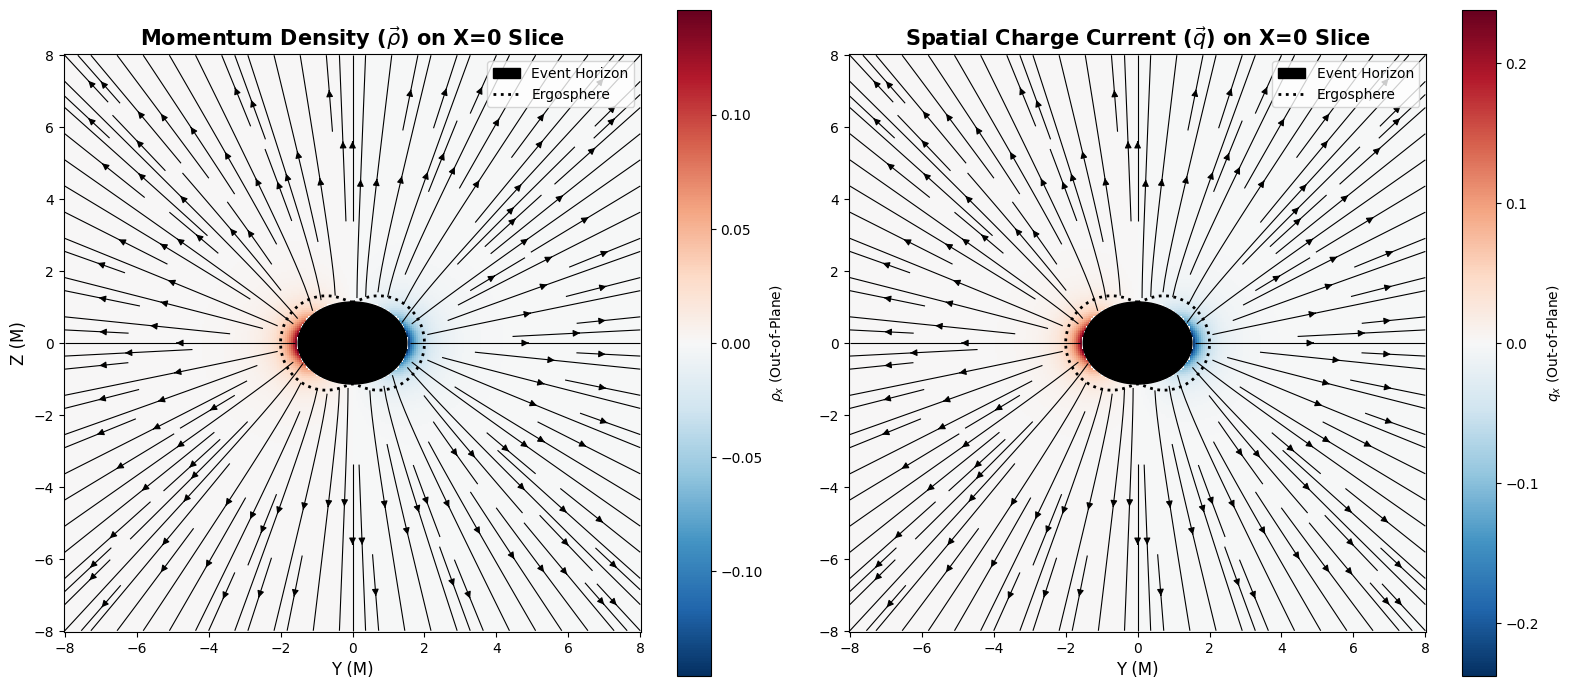

In [89]:
# ==========================================
# MODULE 6: SPATIAL CURRENTS (rho_i, q_i)
# ==========================================

SLICE_PLANE = 'X' # Slice the Cartesian geometry (X, Y, or Z)

m_val = 1.0   
q_val = 0.8   
a_val = 0.99  
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None 
    else: horizon_r = m_val / 2.0
        
    plot_spatial_currents_cartesian(rho_hat, q_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_spatial_currents_spherical(rho_hat, q_hat, r, theta, param_dict, horizon_radius=horizon_r)

In [13]:
def plot_energy_currents_cartesian_s0j0(s_hat, j_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Energy Currents (s, j) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    # 1. Dynamically configure the slice plane
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_idx, v_idx, out_idx = 1, 3, 2  
        h_label, v_label = "X (M)", "Z (M)"
        out_str = "y"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_idx, v_idx, out_idx = 2, 3, 1  
        h_label, v_label = "Y (M)", "Z (M)"
        out_str = "x"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_idx, v_idx, out_idx = 1, 2, 3  
        h_label, v_label = "X (M)", "Y (M)"
        out_str = "z"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    # PHYSICALLY LOCKED TO ROW 0
    s_row, j_row = 0, 0
    
    # 2. Extract and compile
    s_h_expr = s_hat[s_row, h_idx].subs(full_subs, simultaneous=True).doit()
    s_v_expr = s_hat[s_row, v_idx].subs(full_subs, simultaneous=True).doit()
    s_out_expr = s_hat[s_row, out_idx].subs(full_subs, simultaneous=True).doit()

    j_h_expr = j_hat[j_row, h_idx].subs(full_subs, simultaneous=True).doit()
    j_v_expr = j_hat[j_row, v_idx].subs(full_subs, simultaneous=True).doit()
    j_out_expr = j_hat[j_row, out_idx].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    s_h_func, s_v_func, s_out_func = lambdify((h_sym, v_sym), s_h_expr, "numpy", cse=True), lambdify((h_sym, v_sym), s_v_expr, "numpy", cse=True), lambdify((h_sym, v_sym), s_out_expr, "numpy", cse=True)
    j_h_func, j_v_func, j_out_func = lambdify((h_sym, v_sym), j_h_expr, "numpy", cse=True), lambdify((h_sym, v_sym), j_v_expr, "numpy", cse=True), lambdify((h_sym, v_sym), j_out_expr, "numpy", cse=True)

    # 3. Evaluate Grid
    grid_lim = 8.0
    res = 300
    h_vals, v_vals = np.linspace(-grid_lim, grid_lim, res), np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    
    # --- FIX: Define R globally for array sizing BEFORE the mask logic ---
    R = np.sqrt(H_grid**2 + V_grid**2)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), 1.0)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)
    
    if hr > 0 and abs(a_val) > 0 and slice_axis != 'Z':
        # Elliptical mask for highly spinning black holes in Cartesian coordinates
        R_ellipse = np.sqrt((H_grid**2) * (hr**2) / (hr**2 + a_val**2) + V_grid**2)
        mask = R_ellipse > (1.02 * hr)
    else:
        mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
        
    H_safe, V_safe = np.where(mask, H_grid, 1.02 * hr), np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    s_h_num, s_v_num, s_out_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)
    j_h_num, j_v_num, j_out_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)

    s_h_num[mask], s_v_num[mask], s_out_num[mask] = safe_eval(s_h_func, H_safe[mask], V_safe[mask]), safe_eval(s_v_func, H_safe[mask], V_safe[mask]), safe_eval(s_out_func, H_safe[mask], V_safe[mask])
    j_h_num[mask], j_v_num[mask], j_out_num[mask] = safe_eval(j_h_func, H_safe[mask], V_safe[mask]), safe_eval(j_v_func, H_safe[mask], V_safe[mask]), safe_eval(j_out_func, H_safe[mask], V_safe[mask])

    for arr in [s_h_num, s_v_num, s_out_num, j_h_num, j_v_num, j_out_num]: arr[~mask] = np.nan

    # 4. Render Deep-Dive Plot
    print("Rendering Energy Current Slices...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot s_i
    ax1 = axes[0]
    s_max = np.nanmax(np.abs(s_out_num))
    if np.isnan(s_max) or s_max == 0: s_max = 1.0
    cmap1 = ax1.pcolormesh(H_grid, V_grid, s_out_num, shading='auto', cmap='RdBu_r', vmin=-s_max, vmax=s_max)
    # Use four braces to ensure LaTeX renders correctly in an f-string
    label_s = fr"$s_{{\hat{{0}}{out_str}}}$ (Out-of-Plane)"
    label_j = fr"$j_{{\hat{{0}}{out_str}}}$ (Out-of-Plane)"

    fig.colorbar(cmap1, ax=ax1, label=label_s)
    if np.any(np.abs(s_h_num[mask])+np.abs(s_v_num[mask]) > 1e-12):
        ax1.streamplot(h_vals, v_vals, s_h_num, s_v_num, color='black', density=1.5, linewidth=0.8)
    
    ax1.set_aspect('equal')
    ax1.set_title(rf"Poynting Vector ($\vec{{s}}$) on {slice_axis}=0 Slice", fontsize=15, fontweight='bold')
    ax1.set_xlabel(h_label, fontsize=12)
    ax1.set_ylabel(v_label, fontsize=12)

    # Plot j_i
    ax2 = axes[1]
    j_max = np.nanmax(np.abs(j_out_num))
    if np.isnan(j_max) or j_max == 0: j_max = 1.0 
    cmap2 = ax2.pcolormesh(H_grid, V_grid, j_out_num, shading='auto', cmap='RdBu_r', vmin=-j_max, vmax=j_max)
    fig.colorbar(cmap2, ax=ax2, label=label_j)
    if np.any(np.abs(j_h_num[mask])+np.abs(j_v_num[mask]) > 1e-12):
        ax2.streamplot(h_vals, v_vals, j_h_num, j_v_num, color='black', density=1.5, linewidth=0.8)
    
    ax2.set_aspect('equal')
    ax2.set_title(rf"Macroscopic Energy Current ($\vec{{j}}$) on {slice_axis}=0 Slice", fontsize=15, fontweight='bold')
    ax2.set_xlabel(h_label, fontsize=12)

    # --- ADDED: ELLIPTICAL EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    for ax in [ax1, ax2]:
        if hr > 0:
            if abs(a_val) > 0 and slice_axis != 'Z':
                # Oblate Ellipse for the true physical shape of the spinning horizon
                width = 2 * np.sqrt(hr**2 + a_val**2)
                height = 2 * hr
                ax.add_patch(Ellipse((0, 0), width, height, color='black', zorder=10, label='Event Horizon'))
            else:
                ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

        if m_val is not None and abs(a_val) > 0.0:
            theta_ergo = np.linspace(0, 2 * np.pi, 200)
            if slice_axis == 'Z':
                ax.add_patch(plt.Circle((0, 0), 2 * m_val, fill=False, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere'))
            else:
                r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
                h_ergo = r_ergo * np.sin(theta_ergo) 
                v_ergo = r_ergo * np.cos(theta_ergo) 
                ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')
                
        if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
            ax.legend(loc='upper right')
    # -------------------------------------------------------------

    plt.tight_layout()
    plt.show()

def plot_energy_currents_spherical_s0j0(s_hat, j_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Energy Currents (s, j) on the r-theta plane...")
    
    # PHYSICALLY LOCKED TO ROW 0
    s_row, j_row = 0, 0
    
    s_r_expr, s_t_expr, s_p_expr = s_hat[s_row, 1].subs(param_dict, simultaneous=True).doit(), s_hat[s_row, 2].subs(param_dict, simultaneous=True).doit(), s_hat[s_row, 3].subs(param_dict, simultaneous=True).doit()
    j_r_expr, j_t_expr, j_p_expr = j_hat[j_row, 1].subs(param_dict, simultaneous=True).doit(), j_hat[j_row, 2].subs(param_dict, simultaneous=True).doit(), j_hat[j_row, 3].subs(param_dict, simultaneous=True).doit()
    
    print("Compiling AST to C-code (CSE Activated)...")
    s_r_func, s_t_func, s_p_func = lambdify((r_sym, theta_sym), s_r_expr, "numpy", cse=True), lambdify((r_sym, theta_sym), s_t_expr, "numpy", cse=True), lambdify((r_sym, theta_sym), s_p_expr, "numpy", cse=True)
    j_r_func, j_t_func, j_p_func = lambdify((r_sym, theta_sym), j_r_expr, "numpy", cse=True), lambdify((r_sym, theta_sym), j_t_expr, "numpy", cse=True), lambdify((r_sym, theta_sym), j_p_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals, z_vals = np.linspace(-grid_lim, grid_lim, res), np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe, Theta_safe = np.where(mask, R, 1.02 * hr), np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    s_r_num, s_t_num, s_p_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)
    j_r_num, j_t_num, j_p_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)
    
    s_r_num[mask], s_t_num[mask], s_p_num[mask] = safe_eval(s_r_func, R_safe[mask], Theta_safe[mask]), safe_eval(s_t_func, R_safe[mask], Theta_safe[mask]), safe_eval(s_p_func, R_safe[mask], Theta_safe[mask])
    j_r_num[mask], j_t_num[mask], j_p_num[mask] = safe_eval(j_r_func, R_safe[mask], Theta_safe[mask]), safe_eval(j_t_func, R_safe[mask], Theta_safe[mask]), safe_eval(j_p_func, R_safe[mask], Theta_safe[mask])
    
    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    s_x_num = (s_r_num * np.sin(Theta) + s_t_num * np.cos(Theta)) * sign_x
    s_z_num = s_r_num * np.cos(Theta) - s_t_num * np.sin(Theta)
    
    j_x_num = (j_r_num * np.sin(Theta) + j_t_num * np.cos(Theta)) * sign_x
    j_z_num = j_r_num * np.cos(Theta) - j_t_num * np.sin(Theta)
    
    for arr in [s_x_num, s_z_num, s_p_num, j_x_num, j_z_num, j_p_num]: arr[~mask] = np.nan

    print("Rendering Energy Current Slices...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot s_i
    ax1 = axes[0]
    s_max = np.nanmax(np.abs(s_p_num))
    if np.isnan(s_max) or s_max == 0: s_max = 1.0
    cmap1 = ax1.pcolormesh(X, Z, s_p_num, shading='auto', cmap='RdBu_r', vmin=-s_max, vmax=s_max)
    label_s = r"$s_{\hat{0}\hat{\phi}}$ (Out-of-Plane)"
    label_j = r"$j_{\hat{0}\hat{\phi}}$ (Out-of-Plane)"
    fig.colorbar(cmap1, ax=ax1, label=label_s)
    if np.any(np.abs(s_x_num[mask])+np.abs(s_z_num[mask]) > 1e-12):
        ax1.streamplot(x_vals, z_vals, s_x_num, s_z_num, color='black', density=1.5, linewidth=0.8)
    
    ax1.set_aspect('equal')
    ax1.set_title(r"Poynting Vector ($\vec{s}$) on Meridional Plane", fontsize=15, fontweight='bold')
    ax1.set_xlabel("X (M)", fontsize=12)
    ax1.set_ylabel("Z (M)", fontsize=12)

    # Plot j_i
    ax2 = axes[1]
    j_max = np.nanmax(np.abs(j_p_num))
    if np.isnan(j_max) or j_max == 0: j_max = 1.0 
    cmap2 = ax2.pcolormesh(X, Z, j_p_num, shading='auto', cmap='RdBu_r', vmin=-j_max, vmax=j_max)
    fig.colorbar(cmap2, ax=ax2, label=label_j)
    if np.any(np.abs(j_x_num[mask])+np.abs(j_z_num[mask]) > 1e-12):
        ax2.streamplot(x_vals, z_vals, j_x_num, j_z_num, color='black', density=1.5, linewidth=0.8)
    
    ax2.set_aspect('equal')
    ax2.set_title(r"Macroscopic Energy Current ($\vec{j}$) on Meridional Plane", fontsize=15, fontweight='bold')
    ax2.set_xlabel("X (M)", fontsize=12)

    # --- ADDED: EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    for ax in [ax1, ax2]:
        if hr > 0:
            ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

        if m_val is not None and abs(a_val) > 0.0:
            theta_ergo = np.linspace(0, 2 * np.pi, 200)
            r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
            
            # Map the spherical coordinates directly to the plot axes
            h_ergo = r_ergo * np.sin(theta_ergo) 
            v_ergo = r_ergo * np.cos(theta_ergo) 
            
            ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')

        if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
            ax.legend(loc='upper right')
    # --------------------------------------------------

    plt.tight_layout()
    plt.show()

Rigorous Analysis: Energy Currents (s, j) on the X=0 plane...
Compiling AST to C-code (CSE Activated)...
Rendering Energy Current Slices...


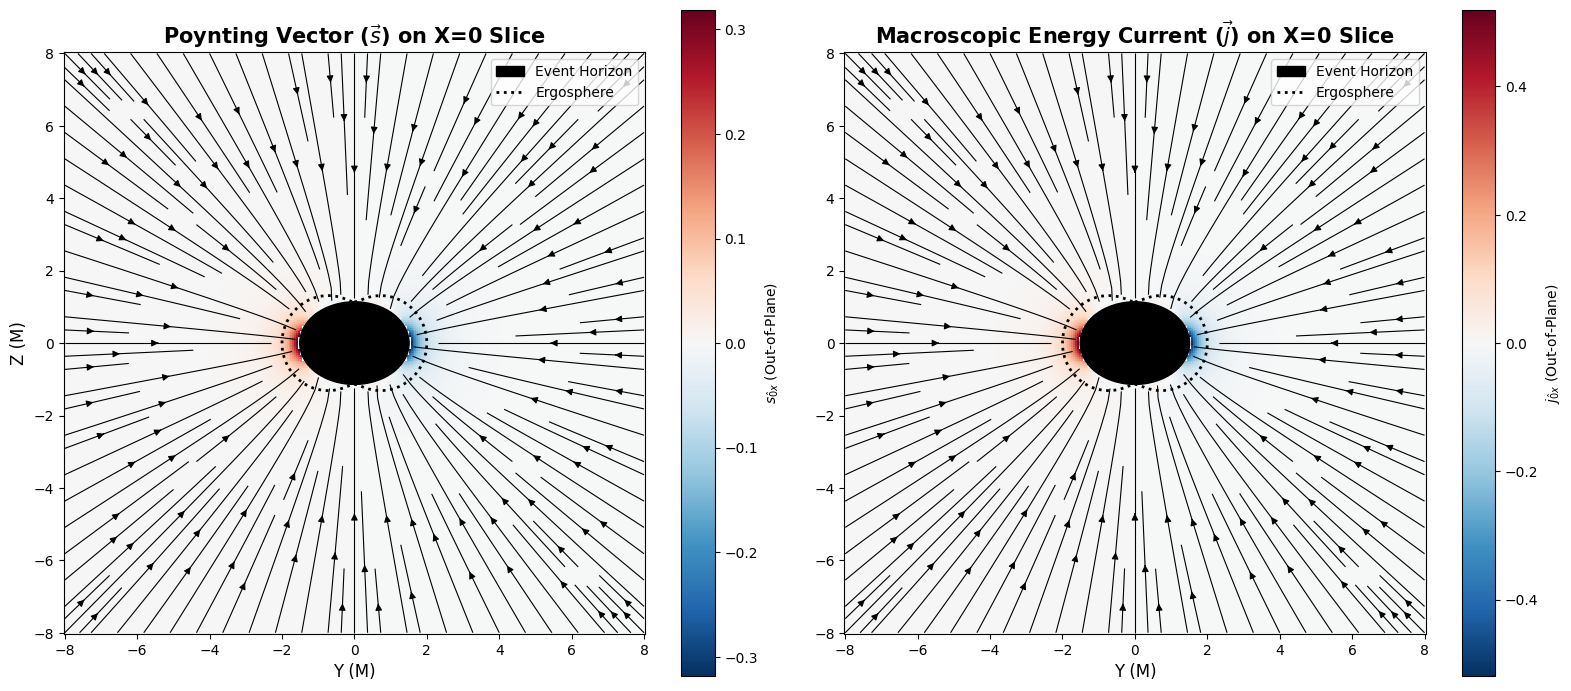

In [90]:
# ==========================================
# MODULE 7: POYNTING AND ENERGY CURRENTS (s0, j0)
# ==========================================

SLICE_PLANE = 'X' # Slice the Cartesian geometry (X, Y, or Z)

m_val = 1.0   
q_val = 0.8   
a_val = 0.99   
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None 
    else: horizon_r = m_val / 2.0
        
    plot_energy_currents_cartesian_s0j0(s_hat, j_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_energy_currents_spherical_s0j0(s_hat, j_hat, r, theta, param_dict, horizon_radius=horizon_r)

In [15]:
#Auto Detector

def plot_energy_currents_cartesian(s_hat, j_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Energy Currents (s, j) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    # 1. Dynamically configure the slice plane
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_idx, v_idx, out_idx = 1, 3, 2  
        h_label, v_label = "X (M)", "Z (M)"
        out_str = "y"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_idx, v_idx, out_idx = 2, 3, 1  
        h_label, v_label = "Y (M)", "Z (M)"
        out_str = "x"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_idx, v_idx, out_idx = 1, 2, 3  
        h_label, v_label = "X (M)", "Y (M)"
        out_str = "z"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    # --- AUTO-DETECTOR: Scan for active vector components ---
    def detect_active_row(matrix):
        best_row, max_act = 0, -1
        for r_idx in range(4):
            expr_h = matrix[r_idx, h_idx].subs(full_subs, simultaneous=True).doit()
            expr_v = matrix[r_idx, v_idx].subs(full_subs, simultaneous=True).doit()
            expr_o = matrix[r_idx, out_idx].subs(full_subs, simultaneous=True).doit()
            act = (1 if expr_h != 0 else 0) + (1 if expr_v != 0 else 0) + (1 if expr_o != 0 else 0)
            if act > max_act: max_act, best_row = act, r_idx
        return best_row, max_act

    s_row, s_act = detect_active_row(s_hat)
    j_row, j_act = detect_active_row(j_hat)
    
    row_labels = ['0', 'x', 'y', 'z']
    s_active = row_labels[s_row]
    j_active = row_labels[j_row]
    
    print(f"\n--- AUTO-DETECTOR ---")
    print(f"Poynting (\u20d7s): Locked onto Row {s_row} (s_{{{s_active}i}}) with {s_act} active components.")
    print(f"Energy Current (\u20d7j): Locked onto Row {j_row} (j_{{{j_active}i}}) with {j_act} active components.")
    print("---------------------\n")

    # 2. Extract and compile
    s_h_expr = s_hat[s_row, h_idx].subs(full_subs, simultaneous=True).doit()
    s_v_expr = s_hat[s_row, v_idx].subs(full_subs, simultaneous=True).doit()
    s_out_expr = s_hat[s_row, out_idx].subs(full_subs, simultaneous=True).doit()

    j_h_expr = j_hat[j_row, h_idx].subs(full_subs, simultaneous=True).doit()
    j_v_expr = j_hat[j_row, v_idx].subs(full_subs, simultaneous=True).doit()
    j_out_expr = j_hat[j_row, out_idx].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    s_h_func, s_v_func, s_out_func = lambdify((h_sym, v_sym), s_h_expr, "numpy", cse=True), lambdify((h_sym, v_sym), s_v_expr, "numpy", cse=True), lambdify((h_sym, v_sym), s_out_expr, "numpy", cse=True)
    j_h_func, j_v_func, j_out_func = lambdify((h_sym, v_sym), j_h_expr, "numpy", cse=True), lambdify((h_sym, v_sym), j_v_expr, "numpy", cse=True), lambdify((h_sym, v_sym), j_out_expr, "numpy", cse=True)

   # 3. Evaluate Grid
    grid_lim = 8.0
    res = 300
    h_vals, v_vals = np.linspace(-grid_lim, grid_lim, res), np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    
    # --- FIX: Define R globally for array sizing BEFORE the mask logic ---
    R = np.sqrt(H_grid**2 + V_grid**2)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), 1.0)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)
    
    if hr > 0 and abs(a_val) > 0 and slice_axis != 'Z':
        # Elliptical mask for highly spinning black holes in Cartesian coordinates
        R_ellipse = np.sqrt((H_grid**2) * (hr**2) / (hr**2 + a_val**2) + V_grid**2)
        mask = R_ellipse > (1.02 * hr)
    else:
        mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
        
    H_safe, V_safe = np.where(mask, H_grid, 1.02 * hr), np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    s_h_num, s_v_num, s_out_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)
    j_h_num, j_v_num, j_out_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)

    s_h_num[mask], s_v_num[mask], s_out_num[mask] = safe_eval(s_h_func, H_safe[mask], V_safe[mask]), safe_eval(s_v_func, H_safe[mask], V_safe[mask]), safe_eval(s_out_func, H_safe[mask], V_safe[mask])
    j_h_num[mask], j_v_num[mask], j_out_num[mask] = safe_eval(j_h_func, H_safe[mask], V_safe[mask]), safe_eval(j_v_func, H_safe[mask], V_safe[mask]), safe_eval(j_out_func, H_safe[mask], V_safe[mask])

    for arr in [s_h_num, s_v_num, s_out_num, j_h_num, j_v_num, j_out_num]: arr[~mask] = np.nan

    # 4. Render Deep-Dive Plot
    print("Rendering Energy Current Slices...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot s_i
    ax1 = axes[0]
    s_max = np.nanmax(np.abs(s_out_num))
    if np.isnan(s_max) or s_max == 0: s_max = 1.0
    cmap1 = ax1.pcolormesh(H_grid, V_grid, s_out_num, shading='auto', cmap='RdBu_r', vmin=-s_max, vmax=s_max)
    fig.colorbar(cmap1, ax=ax1, label=fr"$s_{{{s_active}{out_str}}}$ (Out-of-Plane)")
    if np.any(np.abs(s_h_num[mask])+np.abs(s_v_num[mask]) > 1e-12):
        ax1.streamplot(h_vals, v_vals, s_h_num, s_v_num, color='black', density=1.5, linewidth=0.8)
    
    ax1.set_aspect('equal')
    ax1.set_title(rf"Poynting Vector ($\vec{{s}}$) on {slice_axis}=0 Slice", fontsize=15, fontweight='bold')
    ax1.set_xlabel(h_label, fontsize=12)
    ax1.set_ylabel(v_label, fontsize=12)

    # Plot j_i
    ax2 = axes[1]
    j_max = np.nanmax(np.abs(j_out_num))
    if np.isnan(j_max) or j_max == 0: j_max = 1.0 
    cmap2 = ax2.pcolormesh(H_grid, V_grid, j_out_num, shading='auto', cmap='RdBu_r', vmin=-j_max, vmax=j_max)
    fig.colorbar(cmap2, ax=ax2, label=fr"$j_{{{j_active}{out_str}}}$ (Out-of-Plane)")
    if np.any(np.abs(j_h_num[mask])+np.abs(j_v_num[mask]) > 1e-12):
        ax2.streamplot(h_vals, v_vals, j_h_num, j_v_num, color='black', density=1.5, linewidth=0.8)
    
    ax2.set_aspect('equal')
    ax2.set_title(rf"Macroscopic Energy Current ($\vec{{j}}$) on {slice_axis}=0 Slice", fontsize=15, fontweight='bold')
    ax2.set_xlabel(h_label, fontsize=12)

    # --- ADDED: ELLIPTICAL EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    for ax in [ax1, ax2]:
        if hr > 0:
            if abs(a_val) > 0 and slice_axis != 'Z':
                # Oblate Ellipse for the true physical shape of the spinning horizon
                width = 2 * np.sqrt(hr**2 + a_val**2)
                height = 2 * hr
                ax.add_patch(Ellipse((0, 0), width, height, color='black', zorder=10, label='Event Horizon'))
            else:
                ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

        if m_val is not None and abs(a_val) > 0.0:
            theta_ergo = np.linspace(0, 2 * np.pi, 200)
            if slice_axis == 'Z':
                ax.add_patch(plt.Circle((0, 0), 2 * m_val, fill=False, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere'))
            else:
                r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
                h_ergo = r_ergo * np.sin(theta_ergo) 
                v_ergo = r_ergo * np.cos(theta_ergo) 
                ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')
                
        if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
            ax.legend(loc='upper right')
    # -------------------------------------------------------------

    plt.tight_layout()
    plt.show()

def plot_energy_currents_spherical(s_hat, j_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Energy Currents (s, j) on the r-theta plane...")
    
    def detect_active_row(matrix):
        best_row, max_act = 0, -1
        for r_idx in range(4):
            expr_r = matrix[r_idx, 1].subs(param_dict, simultaneous=True).doit()
            expr_t = matrix[r_idx, 2].subs(param_dict, simultaneous=True).doit()
            expr_p = matrix[r_idx, 3].subs(param_dict, simultaneous=True).doit()
            act = (1 if expr_r != 0 else 0) + (1 if expr_t != 0 else 0) + (1 if expr_p != 0 else 0)
            if act > max_act: max_act, best_row = act, r_idx
        return best_row, max_act

    s_row, s_act = detect_active_row(s_hat)
    j_row, j_act = detect_active_row(j_hat)
    
    row_labels = ['0', 'r', r'\theta', r'\phi']
    s_active, j_active = row_labels[s_row], row_labels[j_row]
    
    print(f"\n--- AUTO-DETECTOR ---")
    print(f"Poynting (\u20d7s): Locked onto Row {s_row} (s_{{{s_active}i}}) with {s_act} active components.")
    print(f"Energy Current (\u20d7j): Locked onto Row {j_row} (j_{{{j_active}i}}) with {j_act} active components.")
    print("---------------------\n")

    s_r_expr, s_t_expr, s_p_expr = s_hat[s_row, 1].subs(param_dict, simultaneous=True).doit(), s_hat[s_row, 2].subs(param_dict, simultaneous=True).doit(), s_hat[s_row, 3].subs(param_dict, simultaneous=True).doit()
    j_r_expr, j_t_expr, j_p_expr = j_hat[j_row, 1].subs(param_dict, simultaneous=True).doit(), j_hat[j_row, 2].subs(param_dict, simultaneous=True).doit(), j_hat[j_row, 3].subs(param_dict, simultaneous=True).doit()
    
    print("Compiling AST to C-code (CSE Activated)...")
    s_r_func, s_t_func, s_p_func = lambdify((r_sym, theta_sym), s_r_expr, "numpy", cse=True), lambdify((r_sym, theta_sym), s_t_expr, "numpy", cse=True), lambdify((r_sym, theta_sym), s_p_expr, "numpy", cse=True)
    j_r_func, j_t_func, j_p_func = lambdify((r_sym, theta_sym), j_r_expr, "numpy", cse=True), lambdify((r_sym, theta_sym), j_t_expr, "numpy", cse=True), lambdify((r_sym, theta_sym), j_p_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals, z_vals = np.linspace(-grid_lim, grid_lim, res), np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe, Theta_safe = np.where(mask, R, 1.02 * hr), np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    s_r_num, s_t_num, s_p_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)
    j_r_num, j_t_num, j_p_num = np.zeros_like(R), np.zeros_like(R), np.zeros_like(R)
    
    s_r_num[mask], s_t_num[mask], s_p_num[mask] = safe_eval(s_r_func, R_safe[mask], Theta_safe[mask]), safe_eval(s_t_func, R_safe[mask], Theta_safe[mask]), safe_eval(s_p_func, R_safe[mask], Theta_safe[mask])
    j_r_num[mask], j_t_num[mask], j_p_num[mask] = safe_eval(j_r_func, R_safe[mask], Theta_safe[mask]), safe_eval(j_t_func, R_safe[mask], Theta_safe[mask]), safe_eval(j_p_func, R_safe[mask], Theta_safe[mask])
    
    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    s_x_num = (s_r_num * np.sin(Theta) + s_t_num * np.cos(Theta)) * sign_x
    s_z_num = s_r_num * np.cos(Theta) - s_t_num * np.sin(Theta)
    
    j_x_num = (j_r_num * np.sin(Theta) + j_t_num * np.cos(Theta)) * sign_x
    j_z_num = j_r_num * np.cos(Theta) - j_t_num * np.sin(Theta)
    
    for arr in [s_x_num, s_z_num, s_p_num, j_x_num, j_z_num, j_p_num]: arr[~mask] = np.nan

    print("Rendering Energy Current Slices...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot s_i
    ax1 = axes[0]
    s_max = np.nanmax(np.abs(s_p_num))
    if np.isnan(s_max) or s_max == 0: s_max = 1.0
    cmap1 = ax1.pcolormesh(X, Z, s_p_num, shading='auto', cmap='RdBu_r', vmin=-s_max, vmax=s_max)
    fig.colorbar(cmap1, ax=ax1, label=fr"$s_{{{s_active}\phi}}$ (Out-of-Plane)")
    if np.any(np.abs(s_x_num[mask])+np.abs(s_z_num[mask]) > 1e-12):
        ax1.streamplot(x_vals, z_vals, s_x_num, s_z_num, color='black', density=1.5, linewidth=0.8)
    
    ax1.set_aspect('equal')
    ax1.set_title(r"Poynting Vector ($\vec{s}$) on Meridional Plane", fontsize=15, fontweight='bold')
    ax1.set_xlabel("X (M)", fontsize=12)
    ax1.set_ylabel("Z (M)", fontsize=12)

    # Plot j_i
    ax2 = axes[1]
    j_max = np.nanmax(np.abs(j_p_num))
    if np.isnan(j_max) or j_max == 0: j_max = 1.0 
    cmap2 = ax2.pcolormesh(X, Z, j_p_num, shading='auto', cmap='RdBu_r', vmin=-j_max, vmax=j_max)
    fig.colorbar(cmap2, ax=ax2, label=fr"$j_{{{j_active}\phi}}$ (Out-of-Plane)")
    if np.any(np.abs(j_x_num[mask])+np.abs(j_z_num[mask]) > 1e-12):
        ax2.streamplot(x_vals, z_vals, j_x_num, j_z_num, color='black', density=1.5, linewidth=0.8)
    
    ax2.set_aspect('equal')
    ax2.set_title(r"Macroscopic Energy Current ($\vec{j}$) on Meridional Plane", fontsize=15, fontweight='bold')
    ax2.set_xlabel("X (M)", fontsize=12)

    # --- ADDED: EVENT HORIZON & ERGOSPHERE OVERLAYS ---
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)

    for ax in [ax1, ax2]:
        if hr > 0:
            ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10, label='Event Horizon'))

        if m_val is not None and abs(a_val) > 0.0:
            theta_ergo = np.linspace(0, 2 * np.pi, 200)
            r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
            
            # Map the spherical coordinates directly to the plot axes
            h_ergo = r_ergo * np.sin(theta_ergo) 
            v_ergo = r_ergo * np.cos(theta_ergo) 
            
            ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10, label='Ergosphere')

        if hr > 0 or (m_val is not None and abs(a_val) > 0.0):
            ax.legend(loc='upper right')
    # --------------------------------------------------

    plt.tight_layout()
    plt.show()

Rigorous Analysis: Energy Currents (s, j) on the Y=0 plane...

--- AUTO-DETECTOR ---
Poynting (⃗s): Locked onto Row 0 (s_{0i}) with 3 active components.
Energy Current (⃗j): Locked onto Row 0 (j_{0i}) with 3 active components.
---------------------

Compiling AST to C-code (CSE Activated)...
Rendering Energy Current Slices...


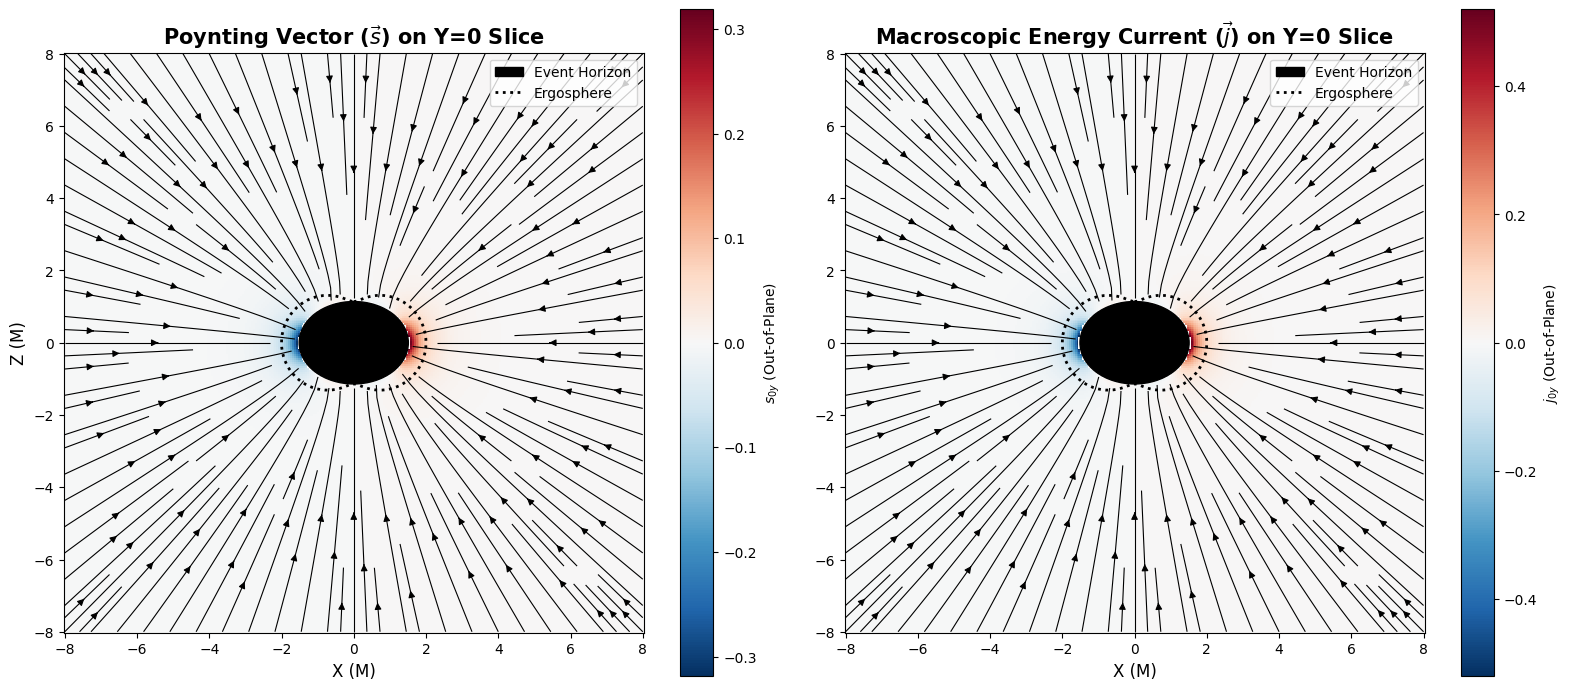

In [92]:
# ==========================================
# MODULE 7: POYNTING AND ENERGY CURRENTS (s0,sij,jij, j0)
# ==========================================

SLICE_PLANE = 'Y' # Slice the Cartesian geometry (X, Y, or Z)

m_val = 1.0   
q_val = 0.8   
a_val = 0.99   
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None 
    else: horizon_r = m_val / 2.0
        
    plot_energy_currents_cartesian(s_hat, j_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_energy_currents_spherical(s_hat, j_hat, r, theta, param_dict, horizon_radius=horizon_r)

In [17]:
def plot_spatial_stress_cartesian(tensor_matrix, matrix_name, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Spatial Stress Tensor ({matrix_name}_ij) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        sym1, sym2 = x_sym, z_sym
        label1, label2 = "X (M)", "Z (M)"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        sym1, sym2 = y_sym, z_sym
        label1, label2 = "Y (M)", "Z (M)"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        sym1, sym2 = x_sym, y_sym
        label1, label2 = "X (M)", "Y (M)"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    print("Compiling 9 spatial components (i,j) to C-code (CSE Activated)...")
    funcs_3x3 = [[None for _ in range(3)] for _ in range(3)]
    for i in range(3):
        for j in range(3):
            expr = tensor_matrix[i+1, j+1].subs(full_subs, simultaneous=True).doit()
            funcs_3x3[i][j] = lambdify((sym1, sym2), expr, "numpy", cse=True)

    # 3. Evaluate Grid & Masks
    grid_lim = 8.0
    res = 200 
    v1_vals = np.linspace(-grid_lim, grid_lim, res)
    v2_vals = np.linspace(-grid_lim, grid_lim, res)
    V1, V2 = np.meshgrid(v1_vals, v2_vals)
    
    # --- FIX: Define globally for array sizing ---
    R = np.sqrt(V1**2 + V2**2)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), 1.0)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)
    
    if hr > 0 and abs(a_val) > 0 and slice_axis != 'Z':
        # Elliptical mask for highly spinning black holes
        R_ellipse = np.sqrt((V1**2) * (hr**2) / (hr**2 + a_val**2) + V2**2)
        mask = R_ellipse > (1.02 * hr)
    else:
        mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    
    V1_safe = np.where(mask, V1, 1.02 * hr)
    V2_safe = np.where(mask, V2, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    grids = [[np.zeros_like(R) for _ in range(3)] for _ in range(3)]
    global_max = 0.0
    
    for i in range(3):
        for j in range(3):
            grids[i][j][mask] = safe_eval(funcs_3x3[i][j], V1_safe[mask], V2_safe[mask])
            grids[i][j][~mask] = np.nan
            local_max = np.nanmax(np.abs(grids[i][j]))
            if local_max > global_max:
                global_max = local_max
                
    if np.isnan(global_max) or global_max == 0: global_max = 1.0

    print("Rendering 3x3 Stress Tensor Grid...")
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    labels = ['x', 'y', 'z']
    
    for i in range(3):
        for j in range(3):
            ax = axes[i, j]
            cmap = ax.pcolormesh(V1, V2, grids[i][j], shading='auto', cmap='RdBu_r', vmin=-global_max, vmax=global_max)
            ax.set_aspect('equal')
            ax.set_title(fr"${matrix_name}_{{{labels[i]} {labels[j]}}}$", fontsize=16)
            if i == 2: ax.set_xlabel(label1, fontsize=12)
            if j == 0: ax.set_ylabel(label2, fontsize=12)
            
            # --- ADDED: ELLIPTICAL EVENT HORIZON & ERGOSPHERE OVERLAYS ---
            if hr > 0:
                if abs(a_val) > 0 and slice_axis != 'Z':
                    width = 2 * np.sqrt(hr**2 + a_val**2)
                    height = 2 * hr
                    ax.add_patch(Ellipse((0, 0), width, height, color='black', zorder=10))
                else:
                    ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10))

            if m_val is not None and abs(a_val) > 0.0:
                theta_ergo = np.linspace(0, 2 * np.pi, 200)
                if slice_axis == 'Z':
                    ax.add_patch(plt.Circle((0, 0), 2 * m_val, fill=False, color='black', linestyle=':', linewidth=2, zorder=10))
                else:
                    r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
                    h_ergo = r_ergo * np.sin(theta_ergo) 
                    v_ergo = r_ergo * np.cos(theta_ergo) 
                    ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10)
            # -------------------------------------------------------------
            
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(cmap, cax=cbar_ax, label=fr"{matrix_name}-Tensor Component Intensity")
    fig.suptitle(fr"Spatial Stress Tensor (${matrix_name}_{{ij}}$) (Slice: {slice_axis}=0)", fontsize=20, fontweight='bold', y=0.95)
    plt.show()

def plot_spatial_stress_spherical(tensor_matrix, matrix_name, r_sym, theta_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Spatial Stress Tensor ({matrix_name}_ij) on the r-theta plane...")
    
    print("Compiling 9 spatial components (i,j) to C-code (CSE Activated)...")
    funcs_3x3 = [[None for _ in range(3)] for _ in range(3)]
    for i in range(3):
        for j in range(3):
            expr = tensor_matrix[i+1, j+1].subs(param_dict, simultaneous=True).doit()
            funcs_3x3[i][j] = lambdify((r_sym, theta_sym), expr, "numpy", cse=True)

    grid_lim = 8.0
    res = 200
    x_vals = np.linspace(-grid_lim, grid_lim, res)
    z_vals = np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    m_val = next((v for k, v in param_dict.items() if str(k) == 'M'), None)
    a_val = next((v for k, v in param_dict.items() if str(k) in ['a', 'a_t']), 0.0)
    
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    
    R_safe = np.where(mask, R, 1.02 * hr)
    Theta_safe = np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    grids = [[np.zeros_like(R) for _ in range(3)] for _ in range(3)]
    global_max = 0.0
    
    for i in range(3):
        for j in range(3):
            grids[i][j][mask] = safe_eval(funcs_3x3[i][j], R_safe[mask], Theta_safe[mask])
            grids[i][j][~mask] = np.nan
            local_max = np.nanmax(np.abs(grids[i][j]))
            if local_max > global_max:
                global_max = local_max
                
    if np.isnan(global_max) or global_max == 0: global_max = 1.0

    print("Rendering 3x3 Stress Tensor Grid...")
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    labels = ['r', r'\theta', r'\phi']
    
    for i in range(3):
        for j in range(3):
            ax = axes[i, j]
            cmap = ax.pcolormesh(X, Z, grids[i][j], shading='auto', cmap='RdBu_r', vmin=-global_max, vmax=global_max)
            ax.set_aspect('equal')
            ax.set_title(fr"${matrix_name}_{{{labels[i]} {labels[j]}}}$", fontsize=16)
            if i == 2: ax.set_xlabel("X (M)", fontsize=12)
            if j == 0: ax.set_ylabel("Z (M)", fontsize=12)
            
            # --- ADDED: EVENT HORIZON & ERGOSPHERE OVERLAYS ---
            if hr > 0:
                ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10))

            if m_val is not None and abs(a_val) > 0.0:
                theta_ergo = np.linspace(0, 2 * np.pi, 200)
                r_ergo = m_val + np.sqrt(np.maximum(0, m_val**2 - a_val**2 * np.cos(theta_ergo)**2))
                
                # Map the spherical coordinates directly to the plot axes
                h_ergo = r_ergo * np.sin(theta_ergo) 
                v_ergo = r_ergo * np.cos(theta_ergo) 
                
                ax.plot(h_ergo, v_ergo, color='black', linestyle=':', linewidth=2, zorder=10)
            # --------------------------------------------------
            
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(cmap, cax=cbar_ax, label=fr"{matrix_name}-Tensor Component Intensity")
    fig.suptitle(fr"Spatial Stress Tensor (${matrix_name}_{{ij}}$) on Meridional Plane", fontsize=20, fontweight='bold', y=0.95)
    plt.show()

Rigorous Analysis: Spatial Stress Tensor (s_ij) on the Z=0 plane...
Compiling 9 spatial components (i,j) to C-code (CSE Activated)...
Rendering 3x3 Stress Tensor Grid...


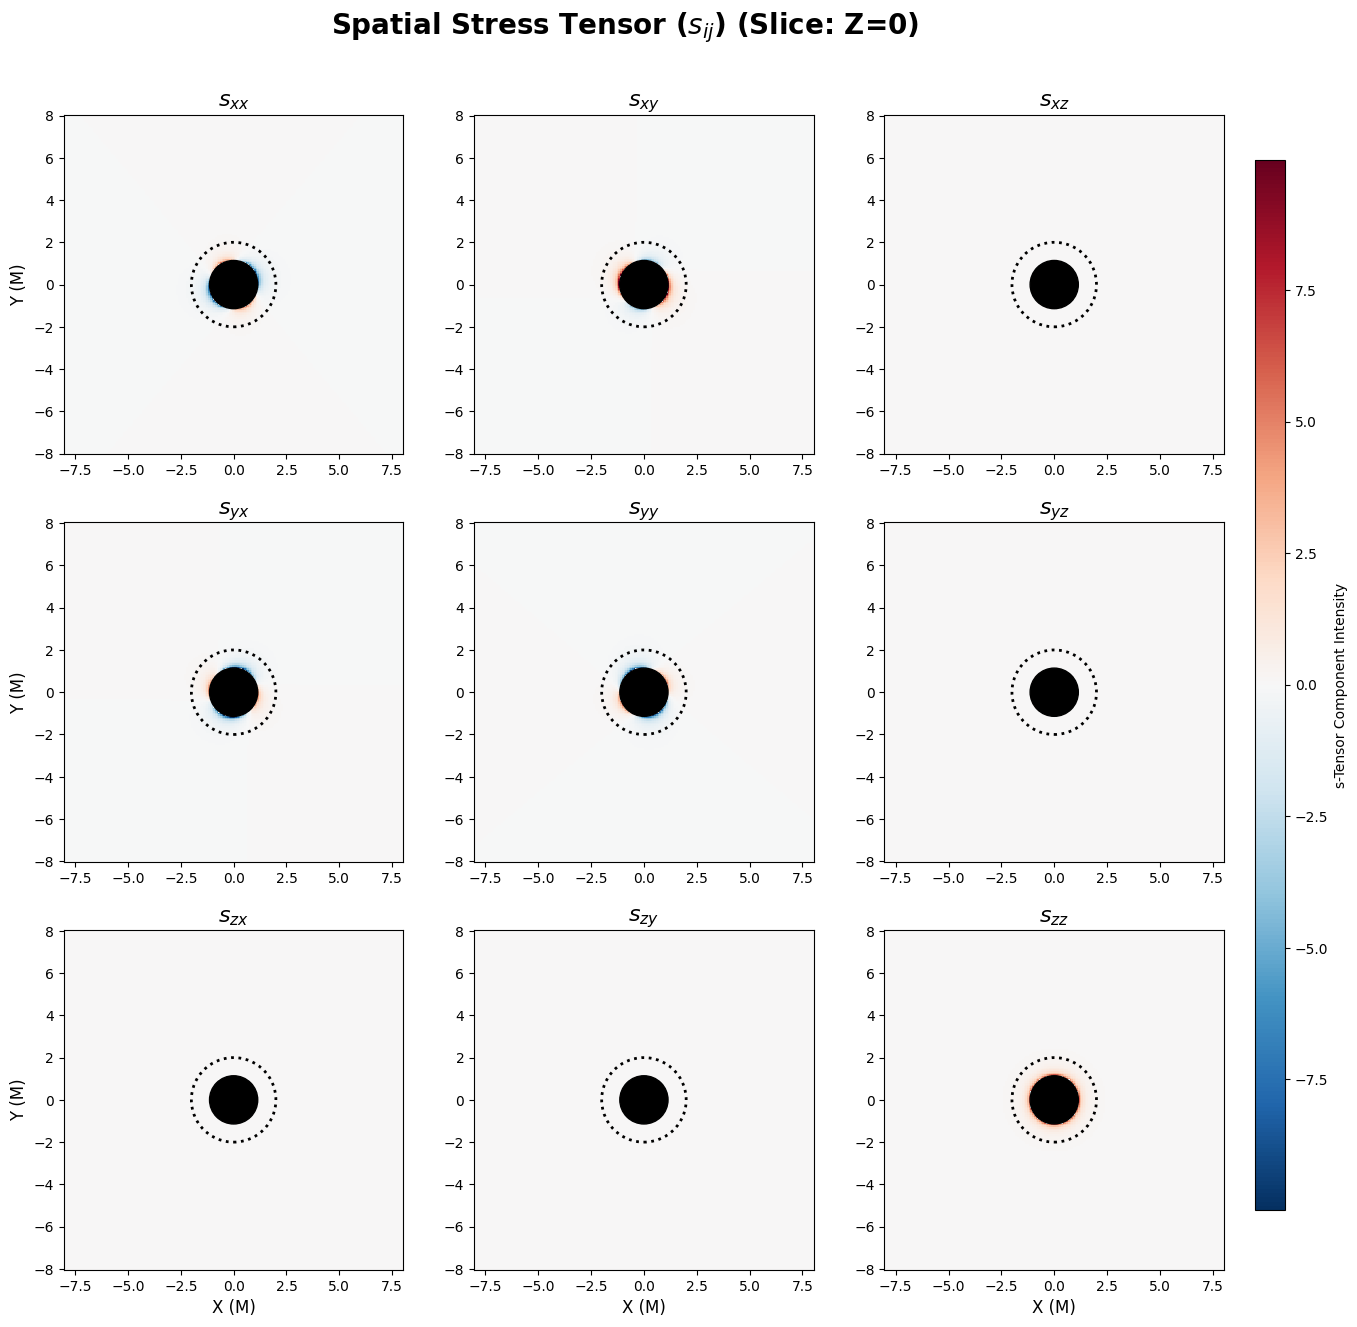

In [94]:
# ==========================================
# MODULE 8: SPATIAL STRESS TENSORS (s_ij, j_ij)
# ==========================================

# 1. Select the Matrix you want to analyze
TARGET_TENSOR = s_hat    # Swap to j_hat to see the macroscopic stress
MATRIX_NAME = "s"        # Change to "j" if you swap above
SLICE_PLANE = 'Z'        # Slice the Cartesian geometry (X, Y, or Z)

# 2. Define physics parameters
m_val = 1.0   
q_val = 0.8   
a_val = 0.99   
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

# 3. Route to the specialized Stress Tensor plotter
if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None 
    else: horizon_r = m_val / 2.0
        
    plot_spatial_stress_cartesian(TARGET_TENSOR, MATRIX_NAME, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_spatial_stress_spherical(TARGET_TENSOR, MATRIX_NAME, r, theta, param_dict, horizon_radius=horizon_r)

In [96]:
# ==========================================
# MODULE 9: ANALYTICAL EXPRESSION EXPORTER (INDEX AWARE)
# ==========================================
import sympy as sp

def export_latex_expressions(tensor, name_symbol, is_spatial_matrix=False, apply_cancel=True, index_style="down"):
    """
    Safely extracts and formats non-zero SymPy tensor components into LaTeX.
    - index_style options: 'down' (e.g., \rho_i), 'up' (e.g., E^{ij}), 'mixed' (e.g., s^i_j)
    """
    print(f"\n% --- LaTeX Output for {name_symbol} ---")
    print(r"\begin{align}")
    
    # 1. Handle 2D Matrices (E, B, D, H, s, j)
    if hasattr(tensor, 'shape') and len(tensor.shape) == 2:
        rows, cols = tensor.shape
        row_start, col_start = (1, 1) if is_spatial_matrix else (0, 0)
        
        for i in range(row_start, rows):
            for j in range(col_start, cols):
                expr = tensor[i, j].doit() 
                if expr != 0:
                    if apply_cancel: expr = sp.cancel(expr)
                    latex_str = sp.latex(expr)
                    
                    # Apply Index Styling
                    if index_style == "up":
                        idx_str = f"^{{{i}{j}}}"
                    elif index_style == "mixed":
                        idx_str = f"^{{{i}}}_{{{j}}}"
                    else:
                        idx_str = f"_{{{i}{j}}}"
                        
                    print(f"    {name_symbol}{idx_str} &= {latex_str} \\\\")
                    
    # 2. Handle 1D Arrays (rho, q)
    else:
        for i in range(len(tensor)):
            expr = tensor[i].doit()
            if expr != 0:
                if apply_cancel: expr = sp.cancel(expr)
                latex_str = sp.latex(expr)
                
                # Apply Index Styling
                idx_str = f"^{{{i}}}" if index_style == "up" else f"_{{{i}}}"
                print(f"    {name_symbol}{idx_str} &= {latex_str} \\\\")
                
    print(r"\end{align}")
    print("% ----------------------------------------\n")

In [97]:
# Extracting 1D Arrays (Covariant)
export_latex_expressions(rho_hat, r"\rho", index_style="down")
export_latex_expressions(q_hat, r"q", index_style="down")

# Extracting 4x4 Fields (Contravariant)
export_latex_expressions(E_hat, r"E", index_style="up")
export_latex_expressions(B_hat, r"B", index_style="up")

# Extracting 4x4 Fields (Mixed)
export_latex_expressions(D_hat, r"D", index_style="mixed")
export_latex_expressions(H_hat, r"H", index_style="mixed")
export_latex_expressions(s_hat, r"s", index_style="mixed")
export_latex_expressions(j_hat, r"j", index_style="mixed")

# # Extracting 3x3 Spatial Tensors (Slices indices 1-3 from the 4x4 matrices)
# export_latex_expressions(s_hat, r"s", is_spatial_matrix=True)

# # Note: Assuming j_hat contains your PRL spatial stress tensor (often denoted t_ij)
# export_latex_expressions(j_hat, r"t", is_spatial_matrix=True)


% --- LaTeX Output for \rho ---
\begin{align}
    \rho_{00} &= \frac{- 64 M^{2} x^{2} - 64 M^{2} y^{2} - 64 M^{2} z^{2}}{M^{6} + 12 M^{5} \sqrt{x^{2} + y^{2} + z^{2}} + 60 M^{4} x^{2} + 60 M^{4} y^{2} + 60 M^{4} z^{2} + 160 M^{3} x^{2} \sqrt{x^{2} + y^{2} + z^{2}} + 160 M^{3} y^{2} \sqrt{x^{2} + y^{2} + z^{2}} + 160 M^{3} z^{2} \sqrt{x^{2} + y^{2} + z^{2}} + 240 M^{2} x^{4} + 480 M^{2} x^{2} y^{2} + 480 M^{2} x^{2} z^{2} + 240 M^{2} y^{4} + 480 M^{2} y^{2} z^{2} + 240 M^{2} z^{4} + 192 M x^{4} \sqrt{x^{2} + y^{2} + z^{2}} + 384 M x^{2} y^{2} \sqrt{x^{2} + y^{2} + z^{2}} + 384 M x^{2} z^{2} \sqrt{x^{2} + y^{2} + z^{2}} + 192 M y^{4} \sqrt{x^{2} + y^{2} + z^{2}} + 384 M y^{2} z^{2} \sqrt{x^{2} + y^{2} + z^{2}} + 192 M z^{4} \sqrt{x^{2} + y^{2} + z^{2}} + 64 x^{6} + 192 x^{4} y^{2} + 192 x^{4} z^{2} + 192 x^{2} y^{4} + 384 x^{2} y^{2} z^{2} + 192 x^{2} z^{4} + 64 y^{6} + 192 y^{4} z^{2} + 192 y^{2} z^{4} + 64 z^{6}} \\
\end{align}
% ----------------------------------------


% --- LaTeX 